In [1]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.signal import savgol_filter
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import r2_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GroupKFold, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from tools import load_all


In [2]:
ppc = [200, 600, 1000, 1400, 1800]
vfl = [0.3, 0.4, 0.5, 0.6]

combinations = list(product(ppc, vfl))

In [3]:
PROJECT_DIR = Path.cwd()  # run the notebook from the repo root
CACHE_DIR = PROJECT_DIR / "cache"
FIG_DIR = PROJECT_DIR / "results" / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SIMS = {}
for p, v in combinations:
    sim_label = f"dx0.1_dt0.095_{p}ppc_{v}vfl"
    sim_path = PROJECT_DIR / "simulations" / sim_label / "weibel.in"
    SIMS[sim_label] = sim_path

sim_labels = list(SIMS.keys())

ELECTRON_SPECIES = ("electrons-up", "electrons-down")

# grid / time parameters (from the deck) - Hardcoded in case no simulation is available
NX = 128
DX = 0.1  # 12.8 / 128 [c/w_p]
DT_DUMP = 0.095  # dt * ndump
TMAX = 40
time_array = np.arange(0, TMAX + DT_DUMP, DT_DUMP)


SPECIES_KEYS = ["n", "vfl1", "vfl2", "vfl3", "ufl1", "P11", "P12", "T11", "Q111", "Q112", "nvfl1"]
FIELD_KEYS = ["b1", "b2", "b3", "e1", "e2", "e3"]


In [4]:
from download_data import download_zenodo_repo

download_zenodo_repo(record_id="21431859", output_dir=CACHE_DIR)


Fetching metadata for Zenodo Record ID: 21431859...
Found 40 files. Starting download...
--------------------------------------------------
Skipping dx0.1_dt0.095_200ppc_0.5vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1800ppc_0.5vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.4vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1800ppc_0.3vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_200ppc_0.3vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.6vfl_fields.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.4vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_1000ppc_0.6vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.3vfl_electrons-up_electrons-down.npz (already completely downloaded).
Skipping dx0.1_dt0.095_600ppc_0.5vfl_field

True

In [5]:
data = load_all(
    "dx0.1_dt0.095_1800ppc_0.6vfl", ["electrons-up", "electrons-down"], simulations=SIMS, cache_dir=CACHE_DIR, fields=FIELD_KEYS
)

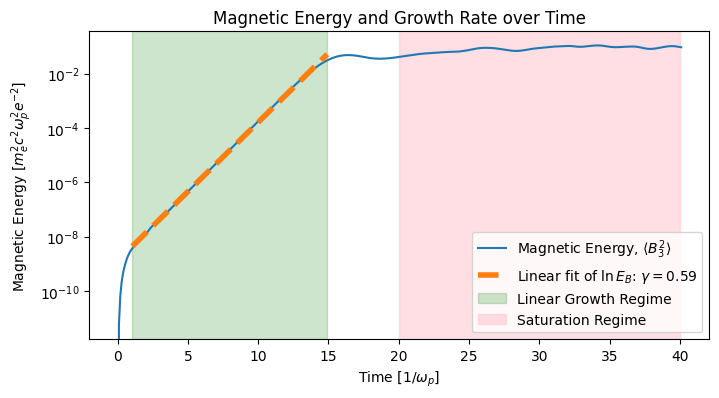

In [6]:
b3 = data["b3"]
magnetic_energy = (np.abs(b3) ** 2).mean(1)

# Fit the growth rate in log space: ln E_B = ln a + 2*gamma*t is linear in t, so an
# ordinary least-squares line weights all times in the window equally. (A nonlinear
# fit of a*exp(b*t) in linear space is dominated by the largest late-time values.)
time_cut = (time_array > 1) & (time_array < 15)
slope, intercept = np.polyfit(time_array[time_cut], np.log(magnetic_energy[time_cut]), 1)
gamma = slope / 2.0
plt.figure(figsize=(8, 4))

plt.plot(
    time_array,
    magnetic_energy,
    label=r"Magnetic Energy, $\langle B_3^2\rangle$",
)
plt.plot(
    time_array[time_cut],
    np.exp(intercept + slope * time_array[time_cut]),
    label=rf"Linear fit of $\ln E_B$: $\gamma = {gamma:.2f}$",
    linestyle="--",
    lw=4,
)
# define regions of interest: linear growth regime and saturation regime
linear_growth_region = (time_array > 1) & (time_array < 15)
saturation_region = (time_array > 20) & (time_array < 40)
plt.axvspan(
    time_array[linear_growth_region][0], time_array[linear_growth_region][-1], color="green", alpha=0.2, label="Linear Growth Regime"
)
plt.axvspan(time_array[saturation_region][0], time_array[saturation_region][-1], color="pink", alpha=0.5, label="Saturation Regime")

plt.xlabel(r"Time $[1/\omega_p]$")
plt.ylabel(r"Magnetic Energy $[m_e^2 c^2 \omega_p^2 e^{-2}]$")
plt.title("Magnetic Energy and Growth Rate over Time")
plt.legend()
plt.yscale("log")


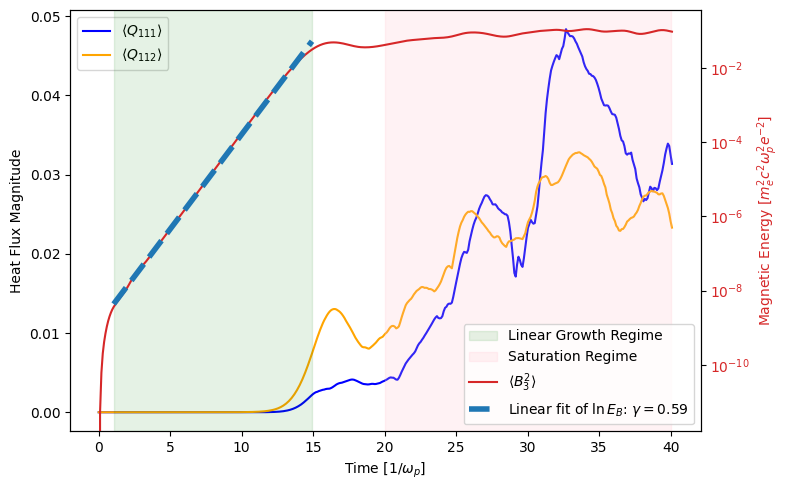

In [7]:
Q111 = data["Q111"]
Q112 = data["Q112"]

plt.figure(figsize=(8, 5))
left_axis = plt.gca()
right_axis = left_axis.twinx()
right_axis.axvspan(
    time_array[linear_growth_region][0], time_array[linear_growth_region][-1], color="green", alpha=0.1, label="Linear Growth Regime"
)
right_axis.axvspan(time_array[saturation_region][0], time_array[saturation_region][-1], color="pink", alpha=0.2, label="Saturation Regime")

left_axis.plot(time_array, np.abs(Q111).mean(1), label=r"$\langle Q_{111} \rangle$", color="blue")
left_axis.plot(time_array, np.abs(Q112).mean(1), label=r"$\langle Q_{112} \rangle$", color="orange")
left_axis.set_ylabel("Heat Flux Magnitude", color="black")
left_axis.tick_params(axis="y", labelcolor="black")

right_axis.plot(time_array, magnetic_energy, label=r"$\langle B_3^2 \rangle$", color="tab:red")
right_axis.plot(
    time_array[time_cut],
    np.exp(intercept + slope * time_array[time_cut]),
    label=rf"Linear fit of $\ln E_B$: $\gamma = {gamma:.2f}$",
    linestyle="--",
    lw=4,
)

right_axis.set_ylabel(r"Magnetic Energy $[m_e^2 c^2 \omega_p^2 e^{-2}]$", color="tab:red")
right_axis.tick_params(axis="y", labelcolor="tab:red")
right_axis.set_yscale("log")

left_axis.legend(loc="upper left")
right_axis.legend(loc="lower right")
# plt.title("Heat Fluxes and Magnetic Energy over Time")
left_axis.set_xlabel(r"Time $[1/\omega_p]$")
plt.tight_layout()
plt.savefig(FIG_DIR / "heat_fluxes_and_magnetic_energy.png", dpi=300)
plt.show()


In [8]:
GMM_DIR = FIG_DIR / "gmm"
GMM_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_LABELS = [
    r"$\log_{10}\langle B_3^2\rangle$",
    r"$\gamma(t)$",
    r"$\log_{10}\langle T_{11}\rangle$",
    r"$\log_{10}\langle Q_{111}^2\rangle$",
]
KS = range(1, 7)
SEED = 0

datasets = sim_labels


In [9]:
def snapshot_features(data_set) -> np.ndarray:

    data = load_all(data_set, ELECTRON_SPECIES, cache_dir=CACHE_DIR, fields=FIELD_KEYS, simulations=SIMS)

    # Magnectic field energy density (B3^2) averaged over x1, for each snapshot in time
    b3sq = (data["b3"].astype(np.float64) ** 2).mean(1)

    # Temperature tensor T11 averaged over x1, for each snapshot in time
    T11 = (data["T11"].astype(np.float64)).mean(1)
    # Third moment tensor Q111 squared, averaged over x1, for each snapshot in time
    q_sq = ((data["Q111"].astype(np.float64)) ** 2).mean(1)

    # Log(B3^2) = 2 * log(B3) = 2 * gamma * t, so the growth rate is given by the derivative of log(B3^2) with respect to time, divided by 2
    ln_b3 = np.log(b3sq + 1e-16)
    growth = savgol_filter(ln_b3, window_length=15, polyorder=2, deriv=1, delta=DT_DUMP) / 2.0
    return np.stack([np.log10(b3sq + 1e-16), growth, np.log10(T11 + 1e-12), np.log10(q_sq + 1e-18)], axis=1)


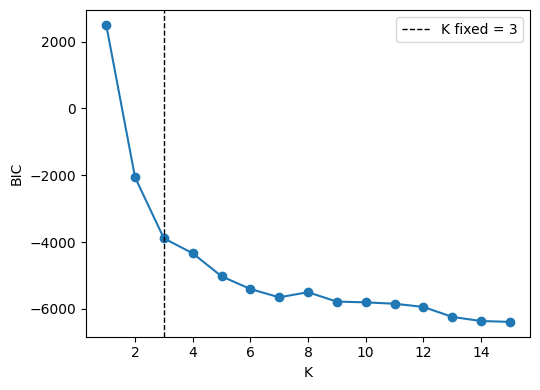

In [10]:
F_diag = snapshot_features(sim_labels[-1])
Xs_diag = StandardScaler().fit_transform(F_diag)
bic_curve = [
    GaussianMixture(n_components=k, covariance_type="full", n_init=5, random_state=SEED).fit(Xs_diag).bic(Xs_diag) for k in range(1, 16)
]
plt.figure(figsize=(5.5, 4))
plt.plot(range(1, 16), bic_curve, "o-")
plt.axvline(3, color="k", ls="--", lw=1, label="K fixed = 3")
plt.xlabel("K")
plt.ylabel("BIC")
plt.legend()
plt.tight_layout()
plt.savefig(GMM_DIR / "bic_vs_K_extended.png", dpi=200)
plt.show()


K=1: BIC=2856.8
K=2: BIC=-2282.2
K=3: BIC=-4016.5
K=4: BIC=-4910.2
K=5: BIC=-5593.7
K=6: BIC=-6300.8


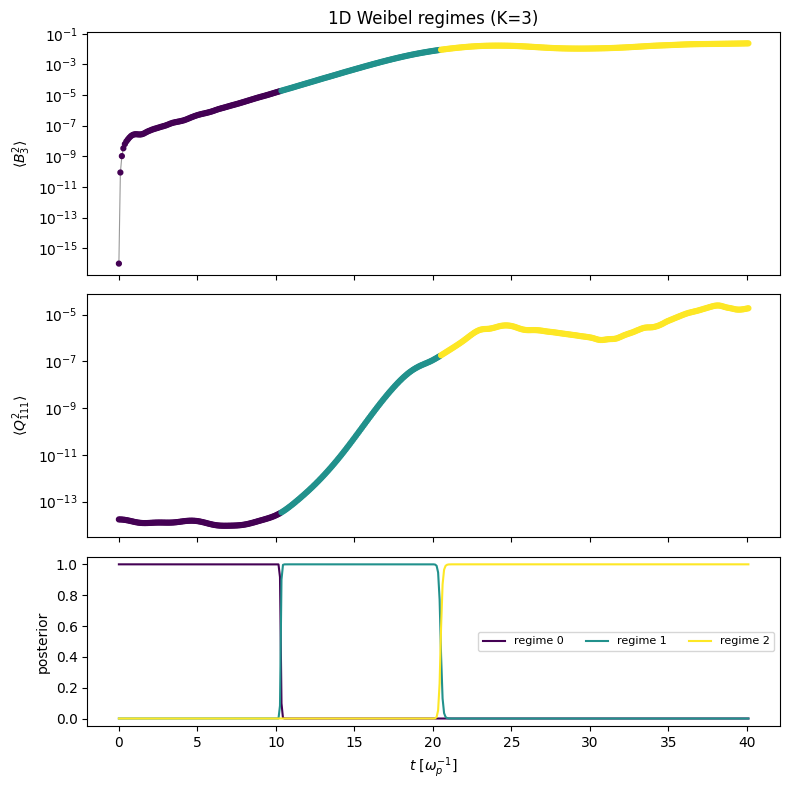

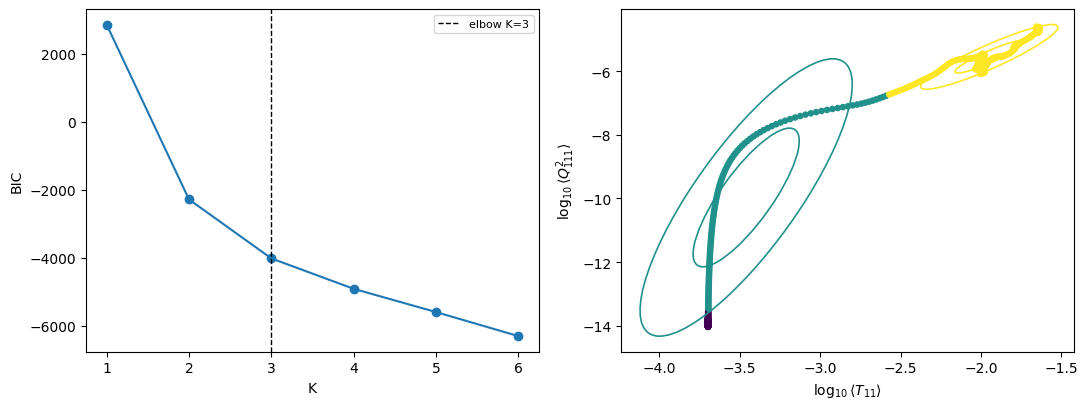

K=1: BIC=2644.8
K=2: BIC=-2159.0
K=3: BIC=-3994.9
K=4: BIC=-4598.4
K=5: BIC=-5353.1
K=6: BIC=-5762.2


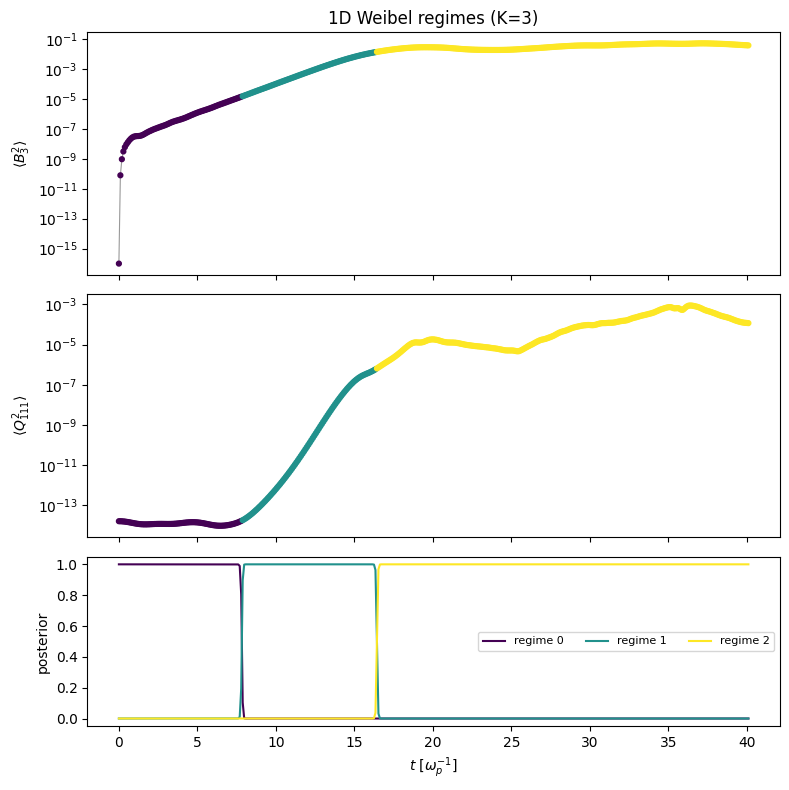

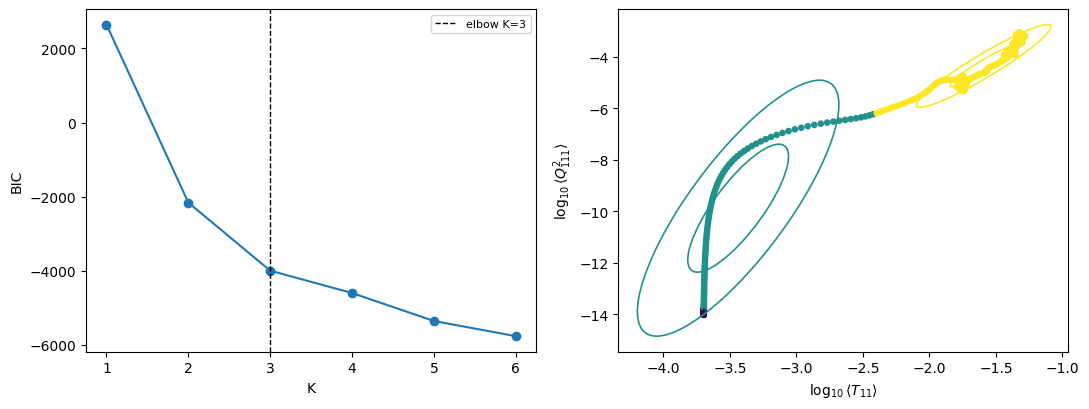

K=1: BIC=2511.1
K=2: BIC=-2198.6
K=3: BIC=-4144.7
K=4: BIC=-4626.6
K=5: BIC=-5233.1
K=6: BIC=-5578.2


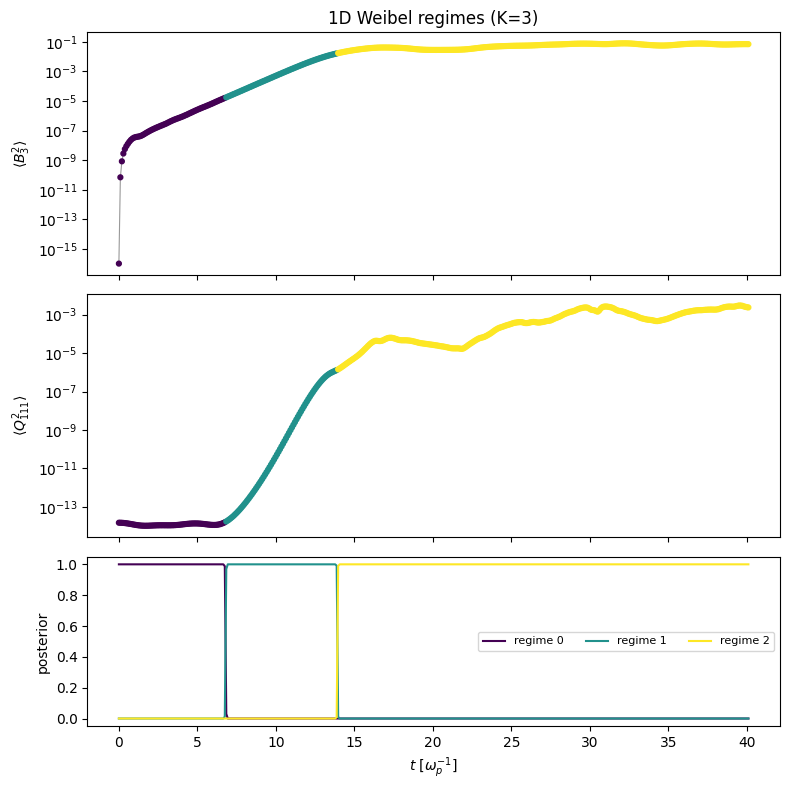

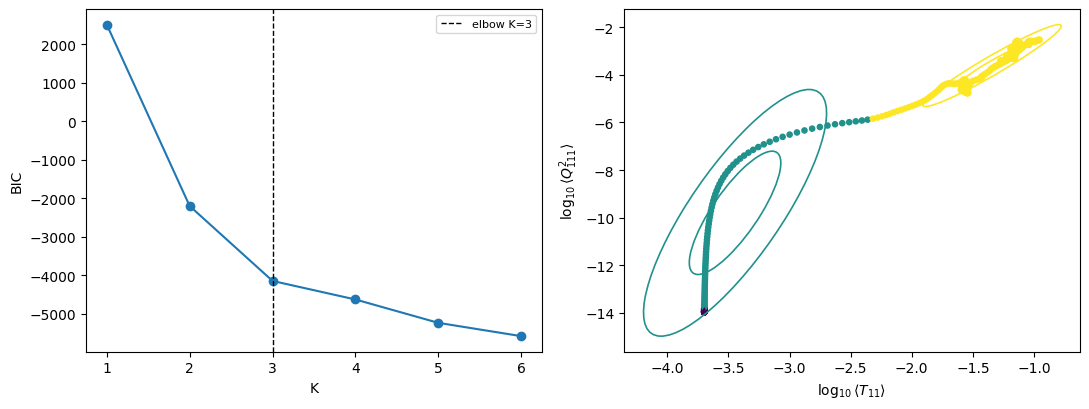

K=1: BIC=2440.3
K=2: BIC=-2087.3
K=3: BIC=-3607.7
K=4: BIC=-4066.1
K=5: BIC=-4712.3
K=6: BIC=-5204.3


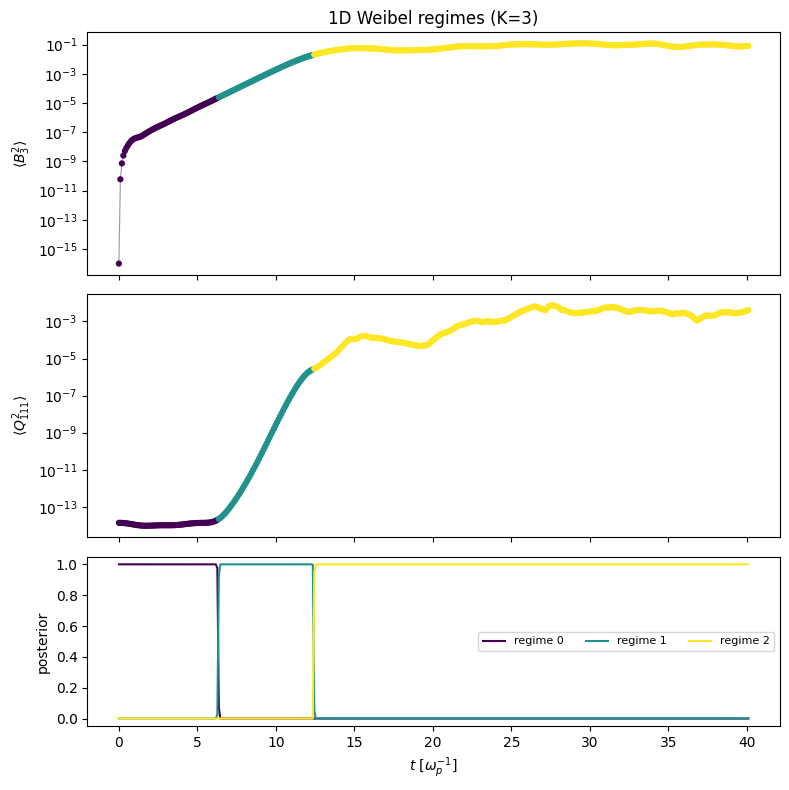

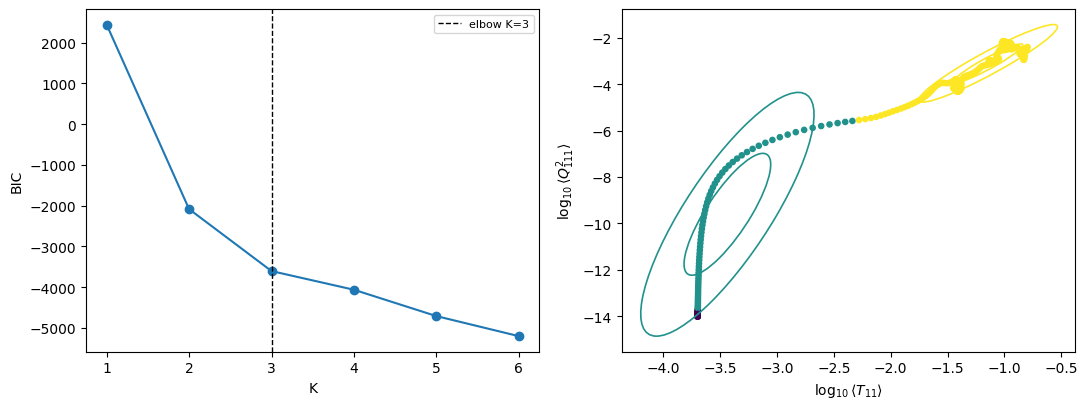

K=1: BIC=2945.4
K=2: BIC=-2358.3
K=3: BIC=-4292.8
K=4: BIC=-5299.4
K=5: BIC=-6200.1
K=6: BIC=-6803.5


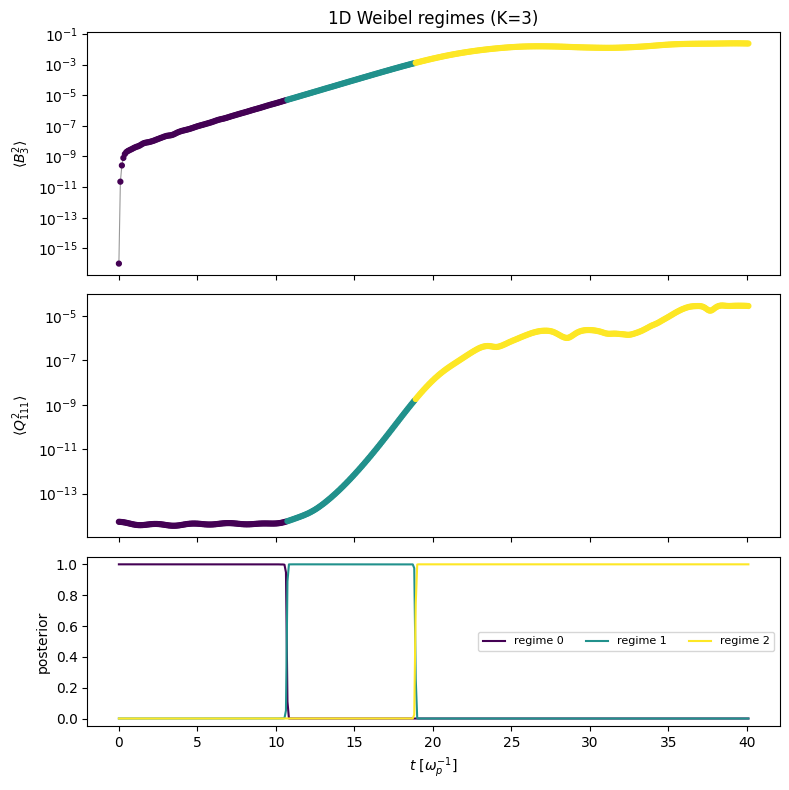

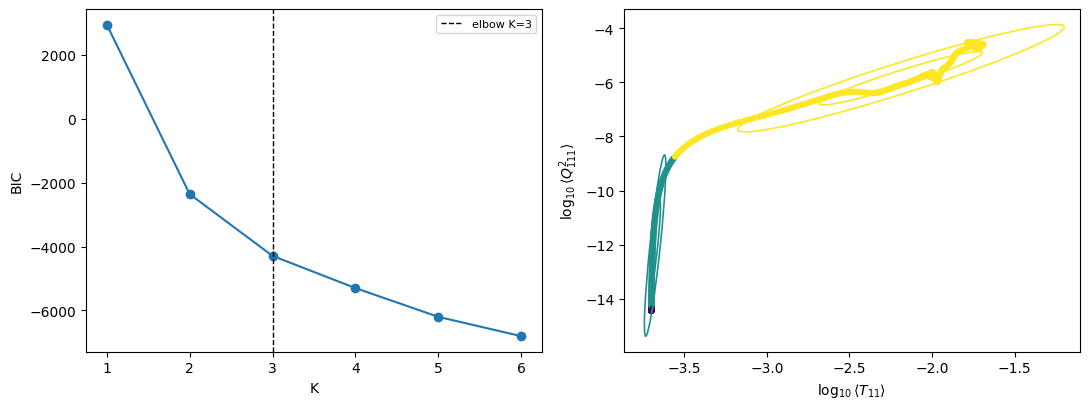

K=1: BIC=2728.8
K=2: BIC=-2281.5
K=3: BIC=-4090.3
K=4: BIC=-5044.9
K=5: BIC=-5695.2
K=6: BIC=-6186.1


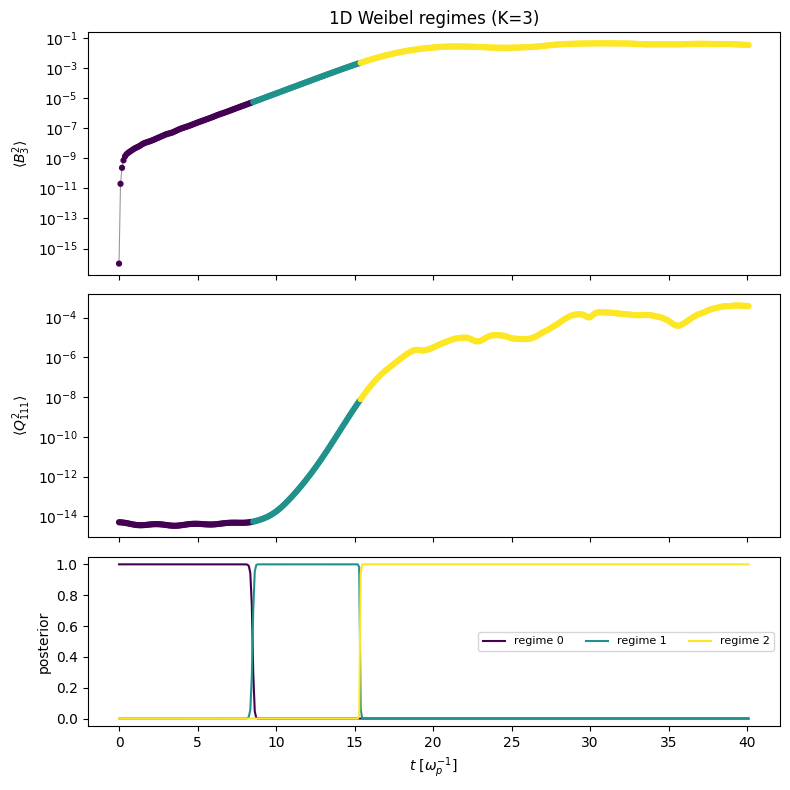

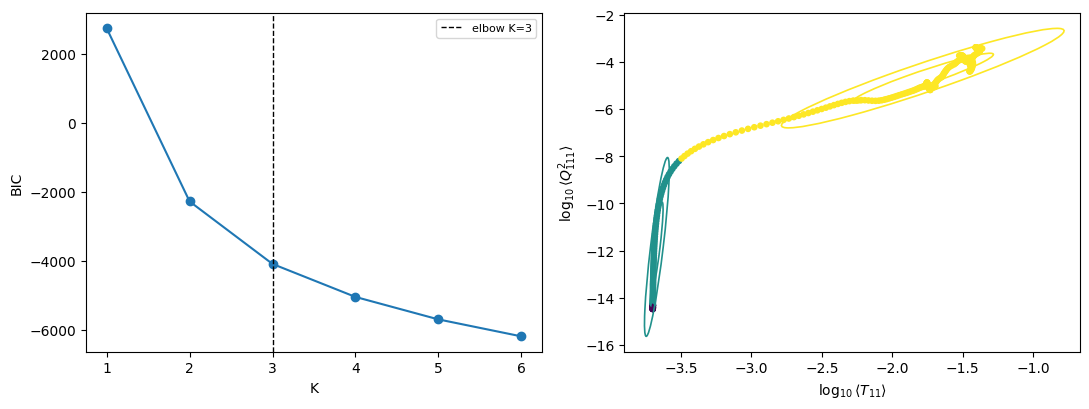

K=1: BIC=2586.6
K=2: BIC=-2141.4
K=3: BIC=-3739.3
K=4: BIC=-4830.8
K=5: BIC=-5262.3
K=6: BIC=-5586.6


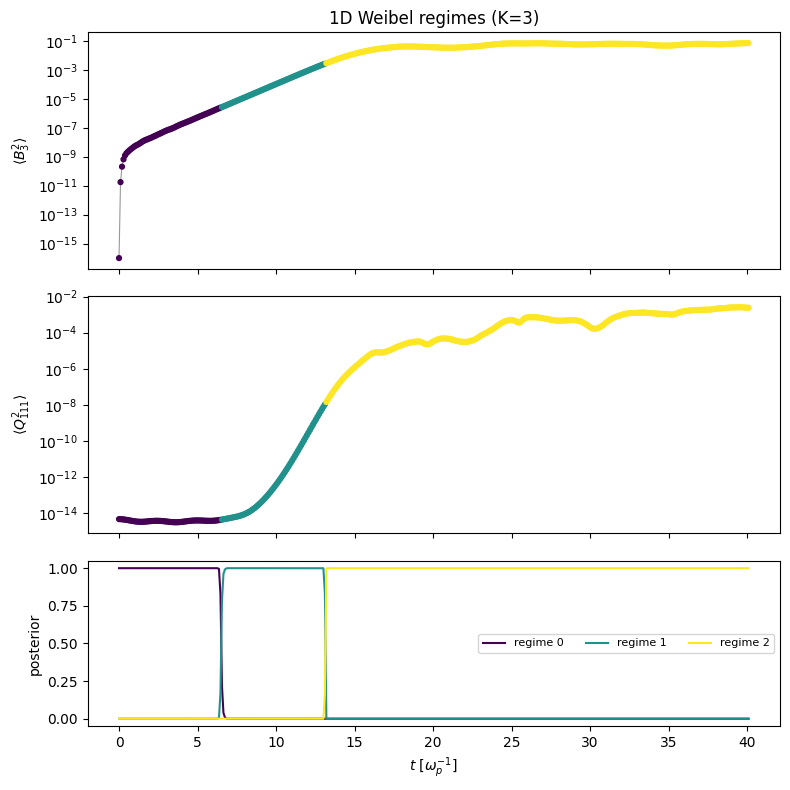

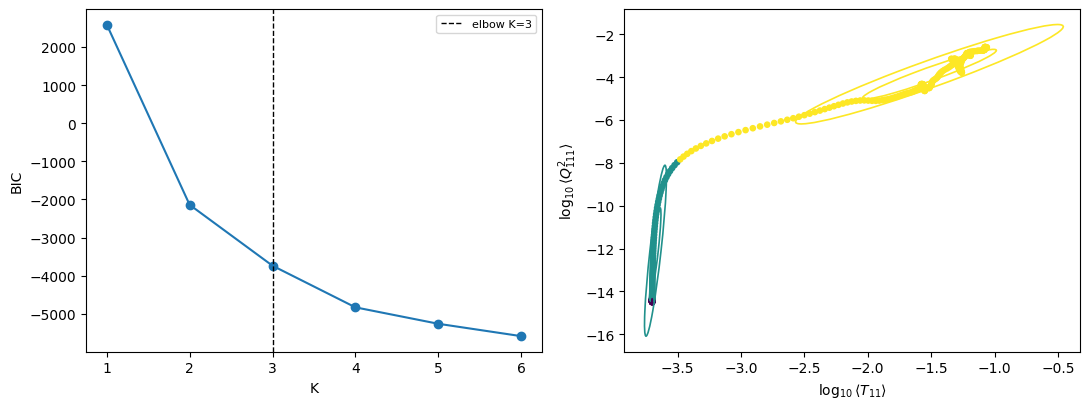

K=1: BIC=2489.5
K=2: BIC=-1930.7
K=3: BIC=-3408.7
K=4: BIC=-4541.0
K=5: BIC=-4906.5
K=6: BIC=-5230.9


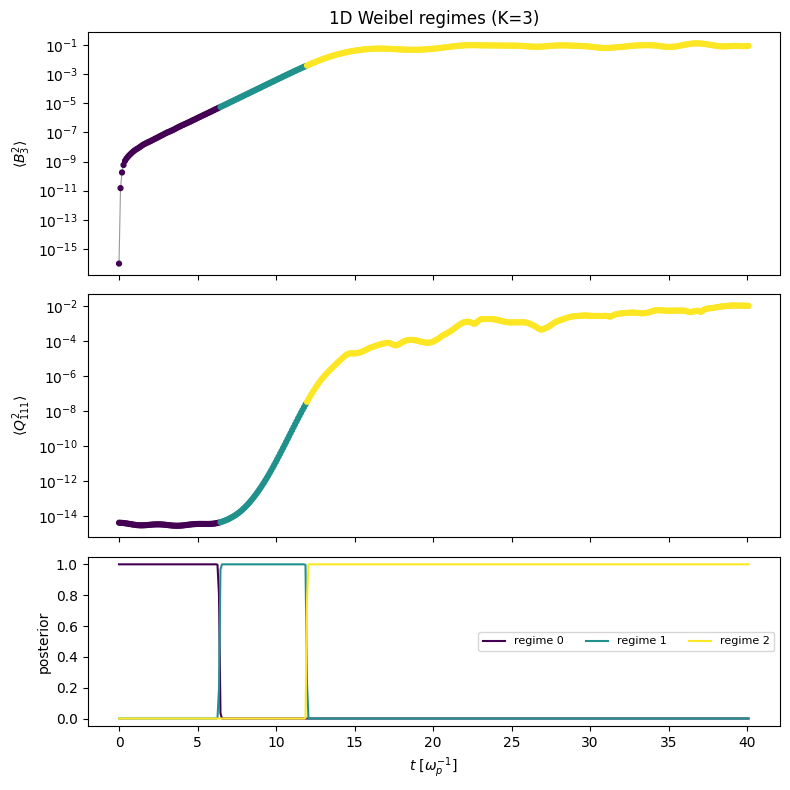

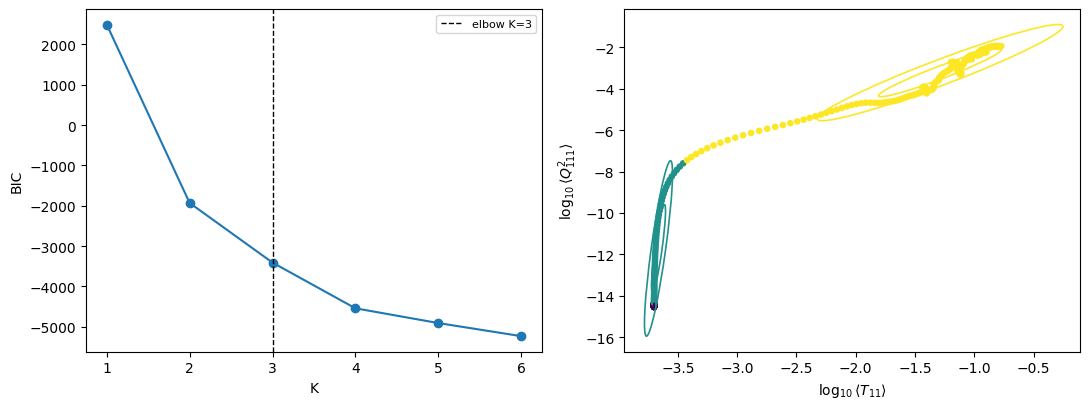

K=1: BIC=2918.5
K=2: BIC=-2708.2
K=3: BIC=-4426.2
K=4: BIC=-5217.7
K=5: BIC=-6219.5
K=6: BIC=-6757.2


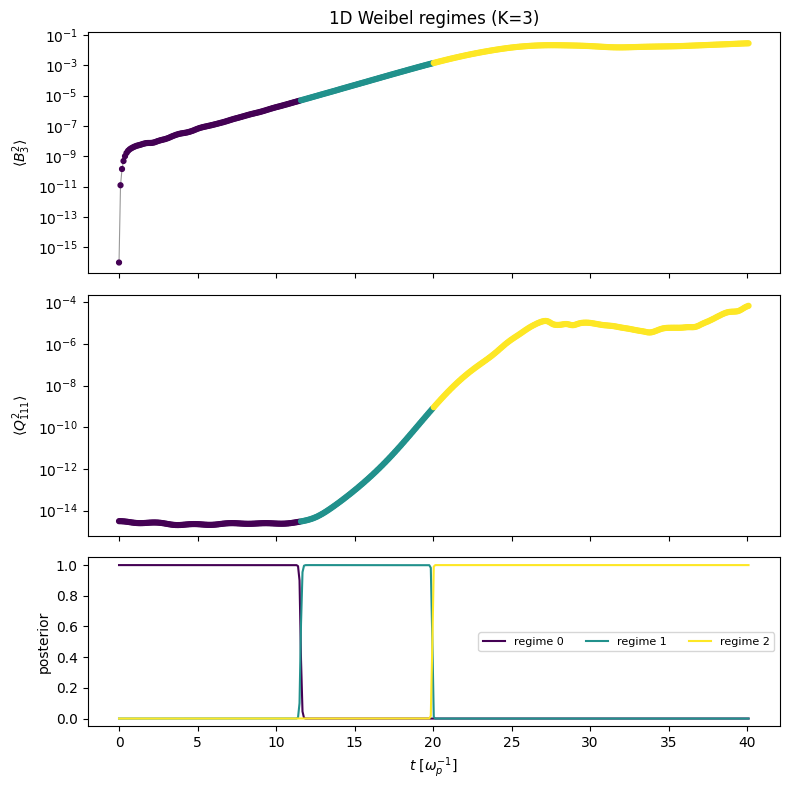

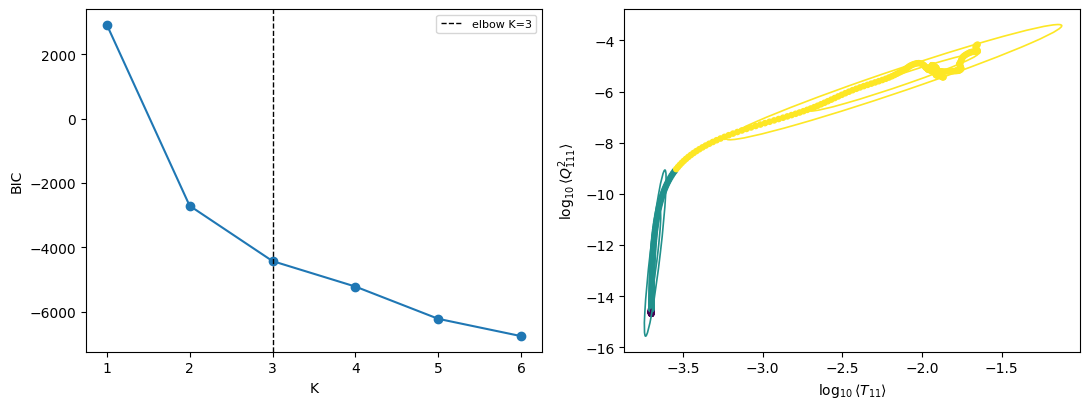

K=1: BIC=2674.5
K=2: BIC=-2372.5
K=3: BIC=-4137.5
K=4: BIC=-4938.8
K=5: BIC=-5581.1
K=6: BIC=-6006.0


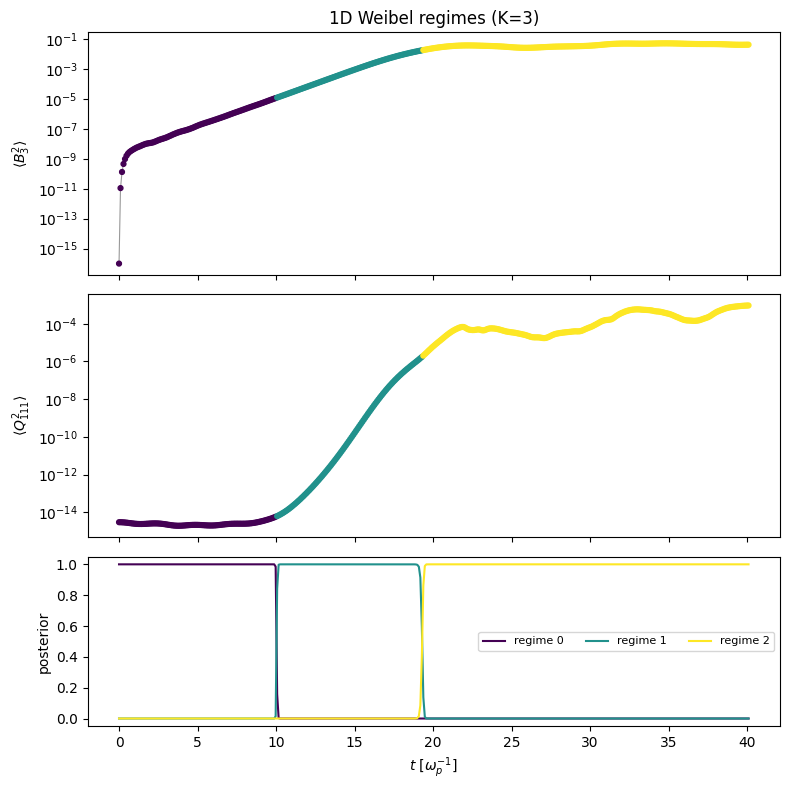

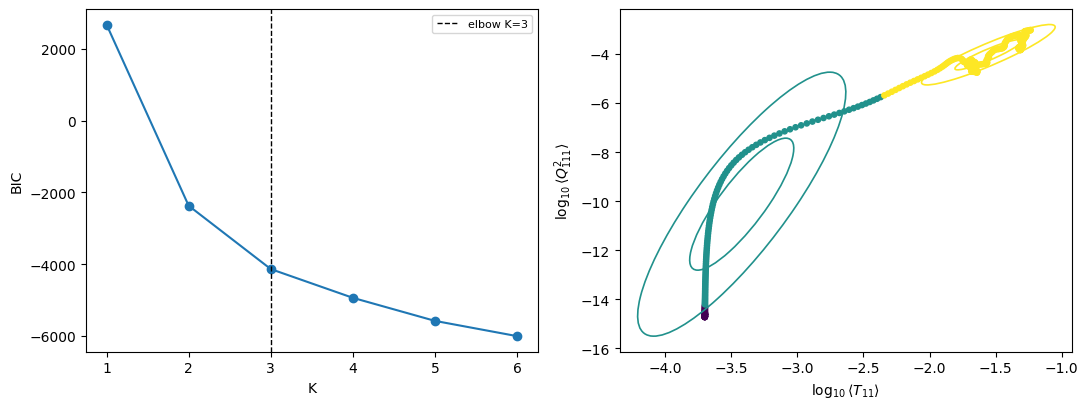

K=1: BIC=2529.2
K=2: BIC=-2351.3
K=3: BIC=-4097.2
K=4: BIC=-4813.2
K=5: BIC=-5386.8
K=6: BIC=-5799.2


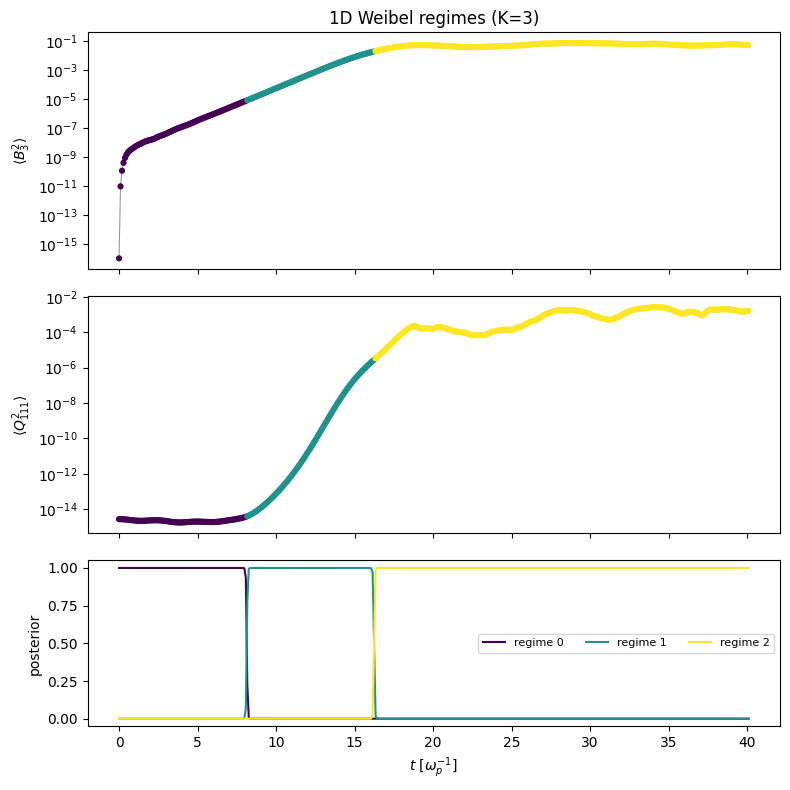

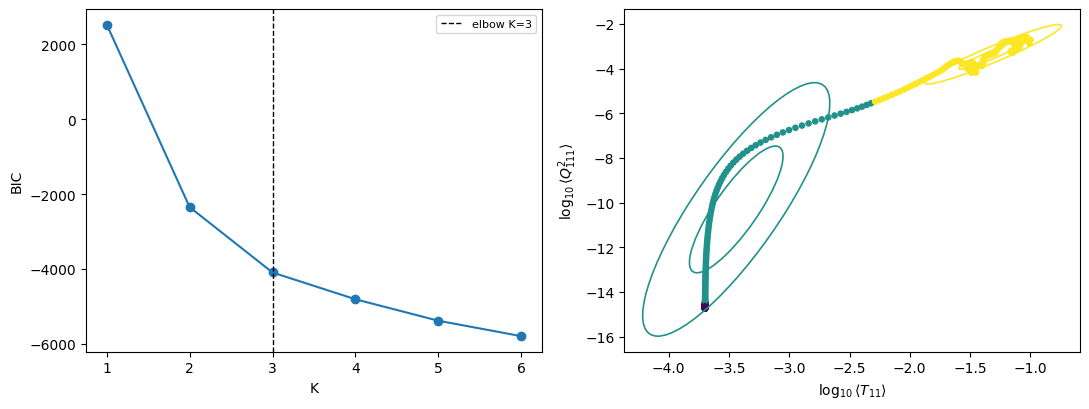

K=1: BIC=2449.2
K=2: BIC=-2195.6
K=3: BIC=-3651.0
K=4: BIC=-4460.7
K=5: BIC=-5002.5
K=6: BIC=-5549.8


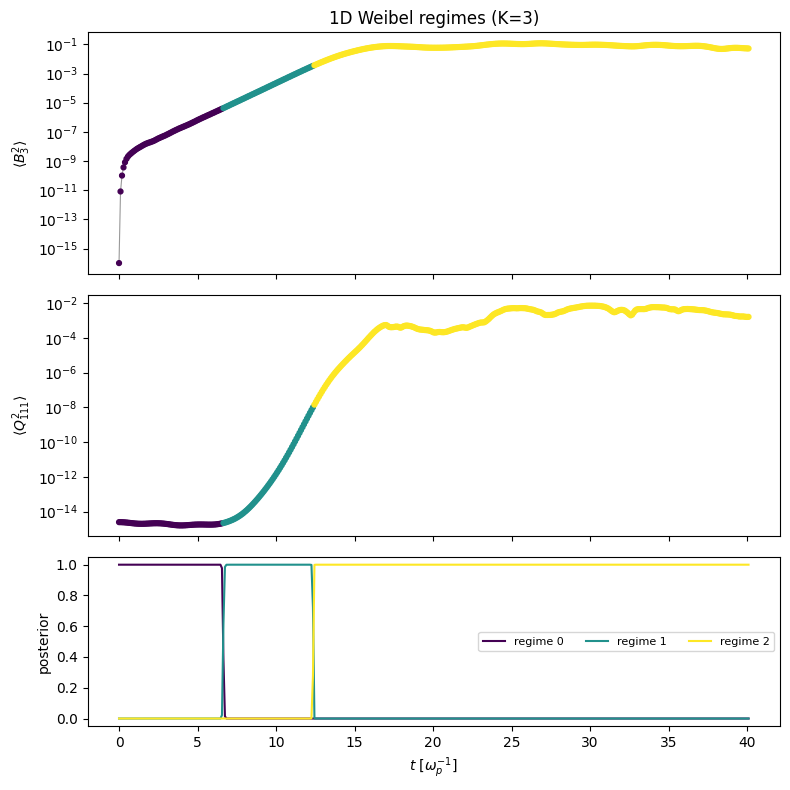

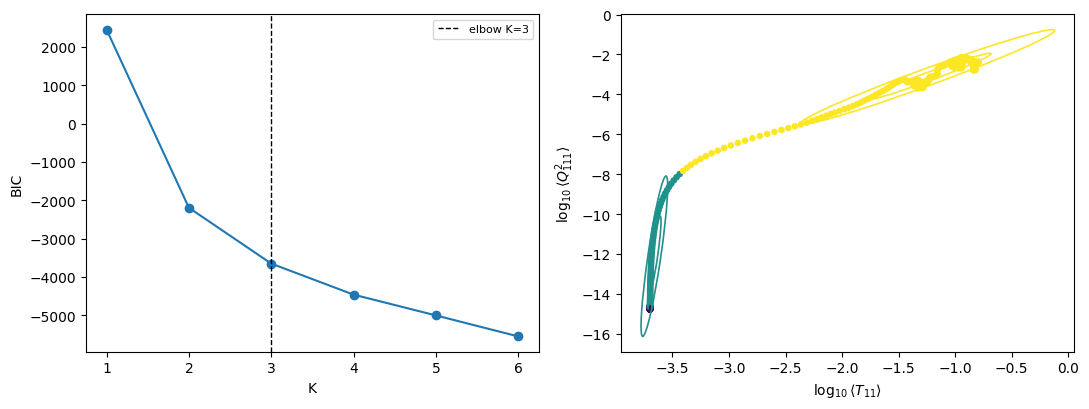

K=1: BIC=2903.8
K=2: BIC=-2613.4
K=3: BIC=-4527.7
K=4: BIC=-5252.7
K=5: BIC=-6251.3
K=6: BIC=-7029.4


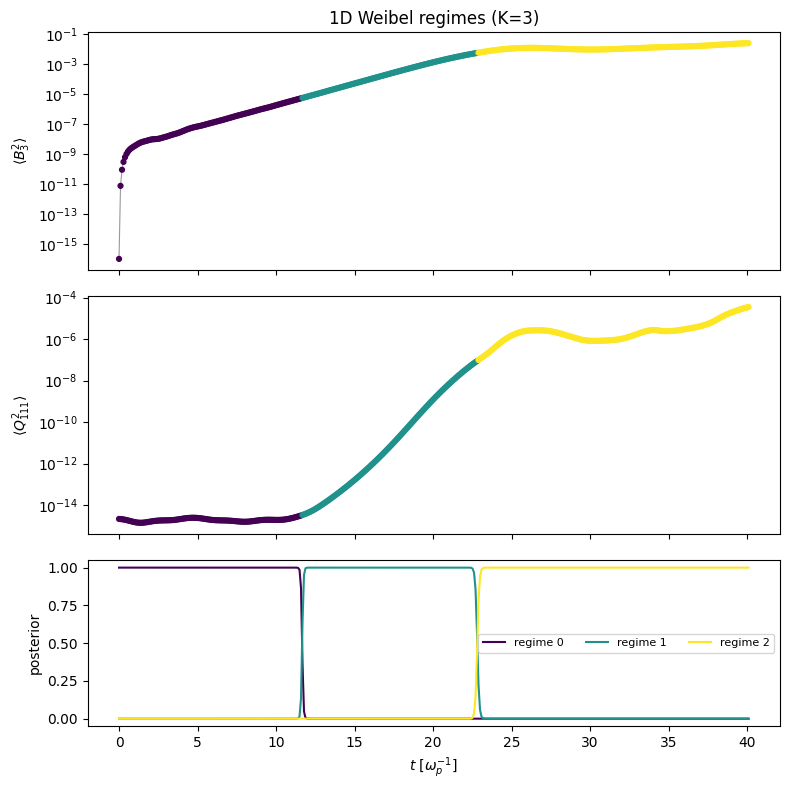

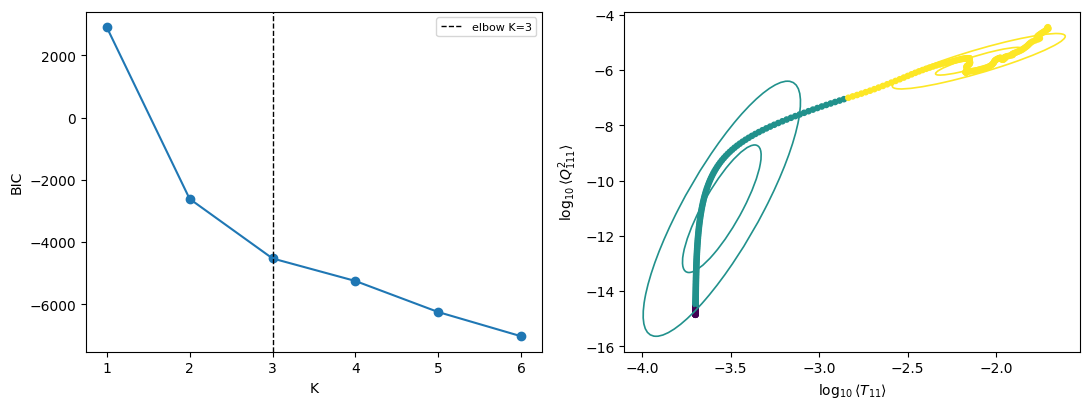

K=1: BIC=2621.2
K=2: BIC=-2357.5
K=3: BIC=-4244.3
K=4: BIC=-4918.5
K=5: BIC=-5671.3
K=6: BIC=-6085.6


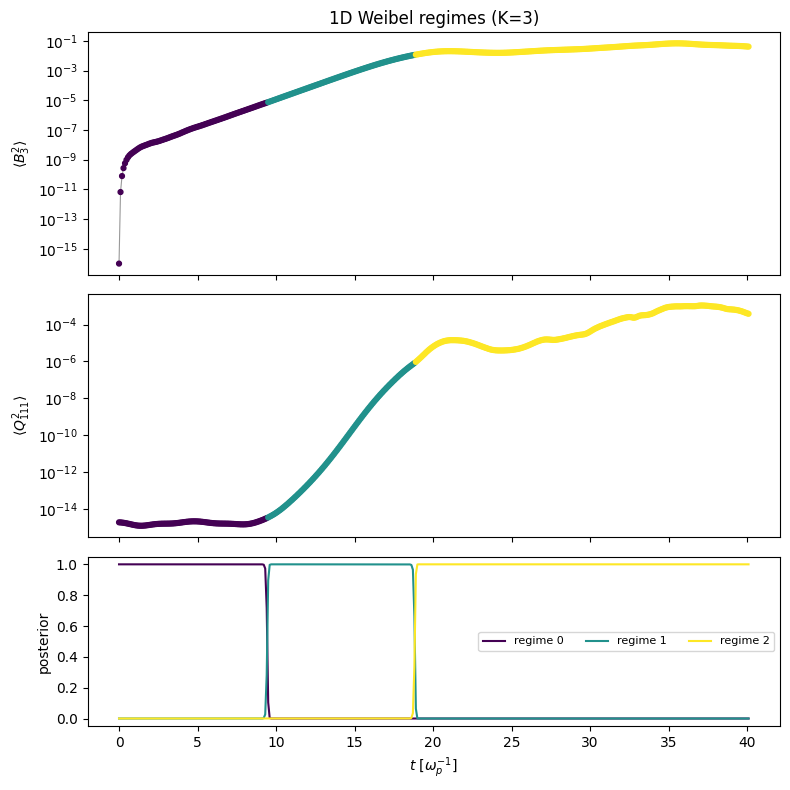

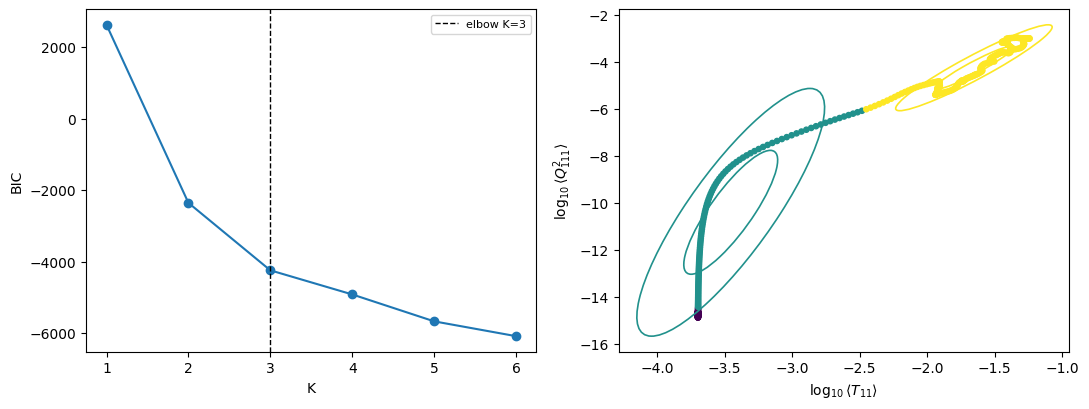

K=1: BIC=2486.9
K=2: BIC=-2050.2
K=3: BIC=-3603.4
K=4: BIC=-4175.5
K=5: BIC=-4850.5
K=6: BIC=-5297.1


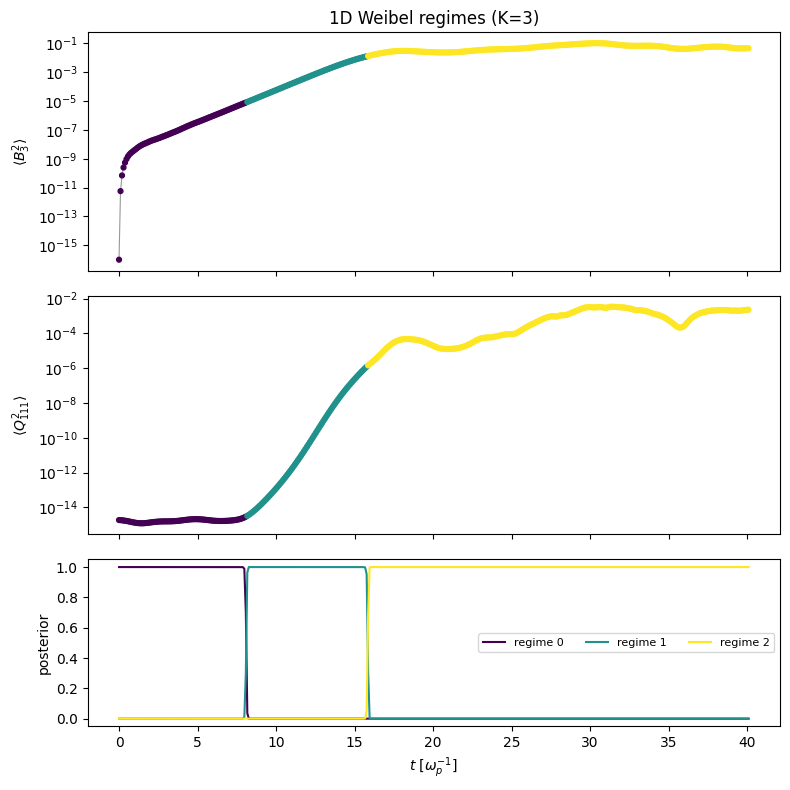

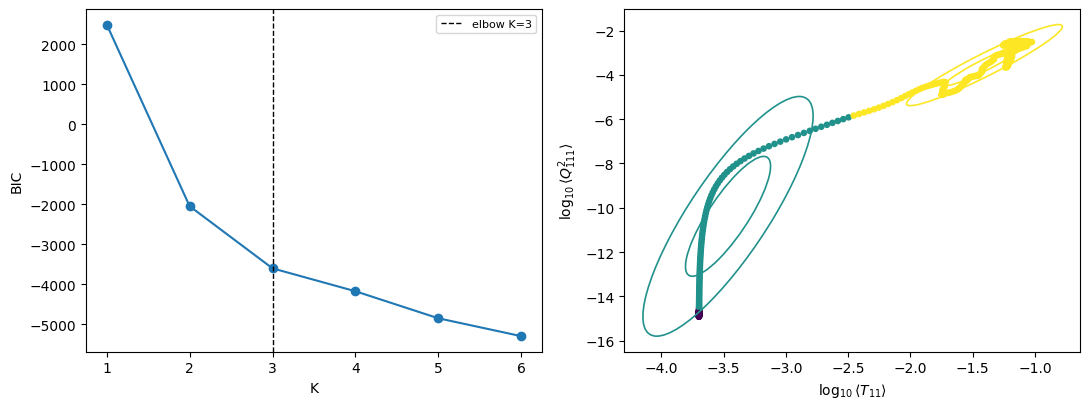

K=1: BIC=2409.0
K=2: BIC=-1859.0
K=3: BIC=-3199.2
K=4: BIC=-3857.0
K=5: BIC=-4543.2
K=6: BIC=-4984.6


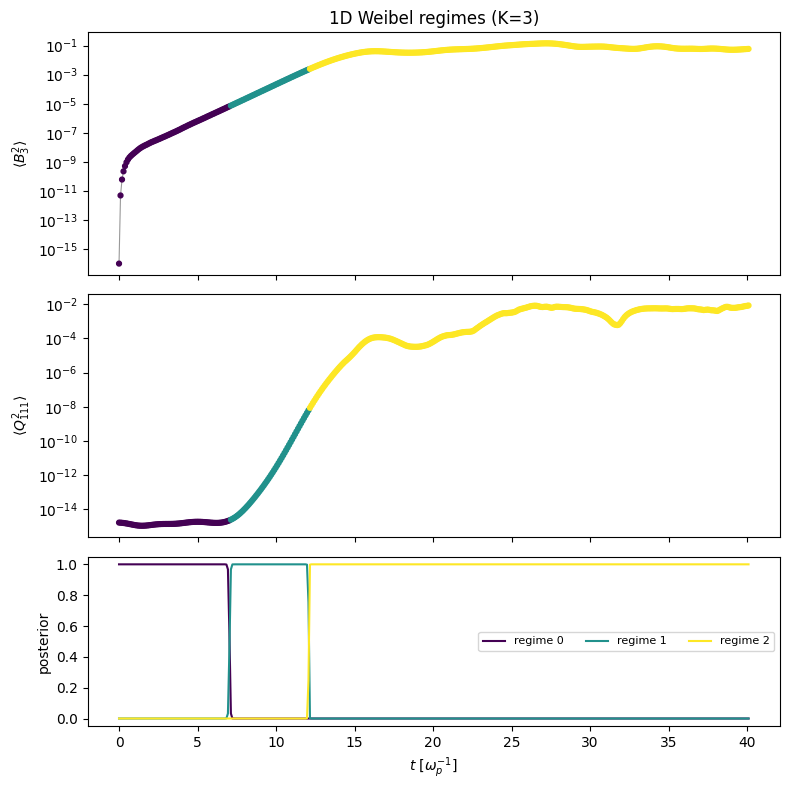

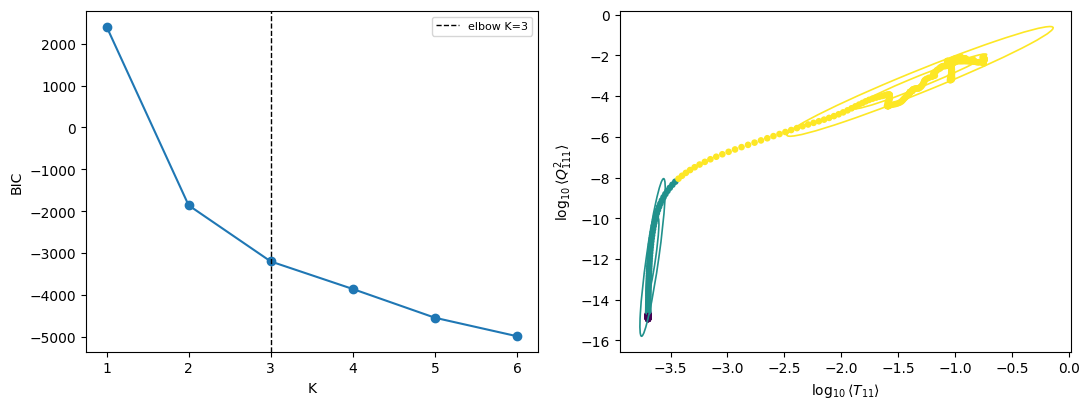

K=1: BIC=2989.6
K=2: BIC=-2358.4
K=3: BIC=-4299.1
K=4: BIC=-5128.0
K=5: BIC=-6276.4
K=6: BIC=-6764.7


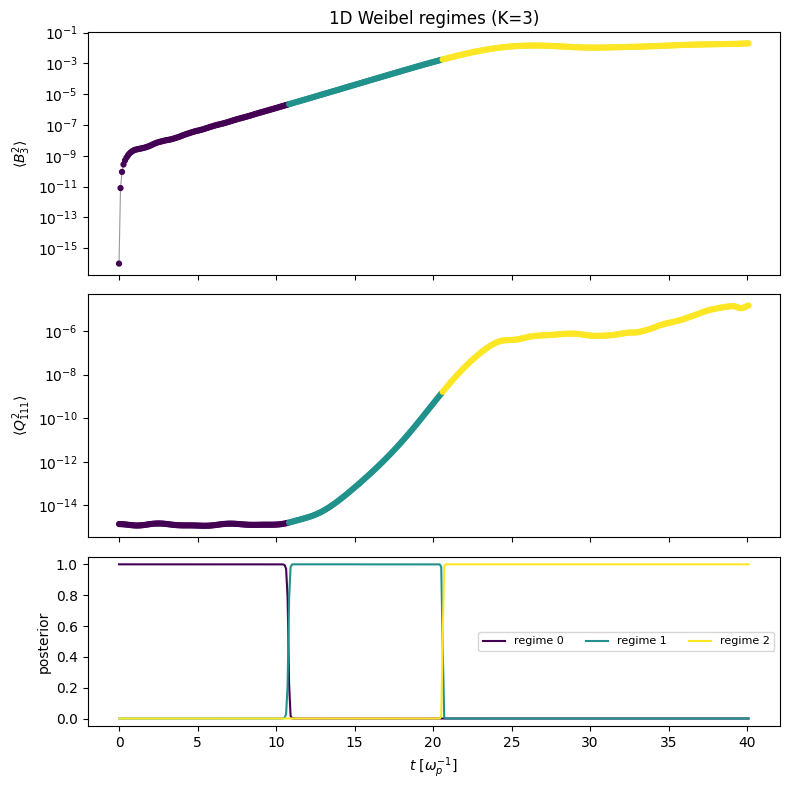

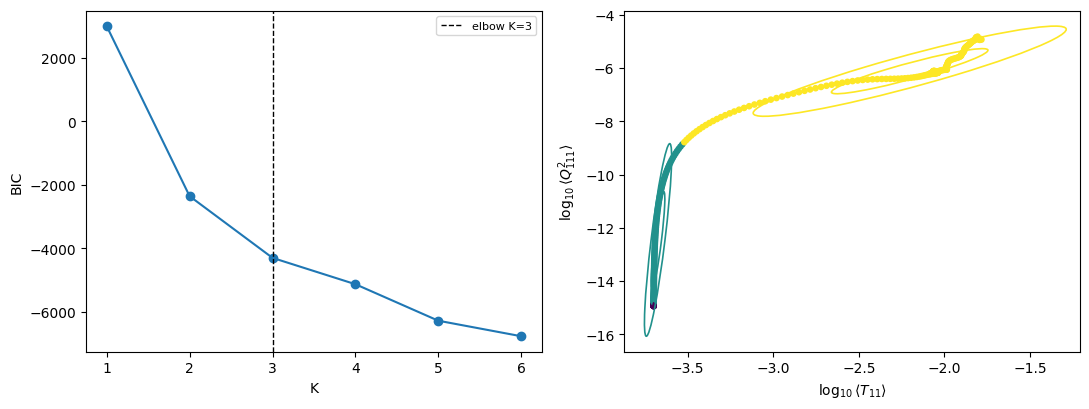

K=1: BIC=2739.3
K=2: BIC=-2040.9
K=3: BIC=-4092.3
K=4: BIC=-4715.3
K=5: BIC=-5793.1
K=6: BIC=-6307.3


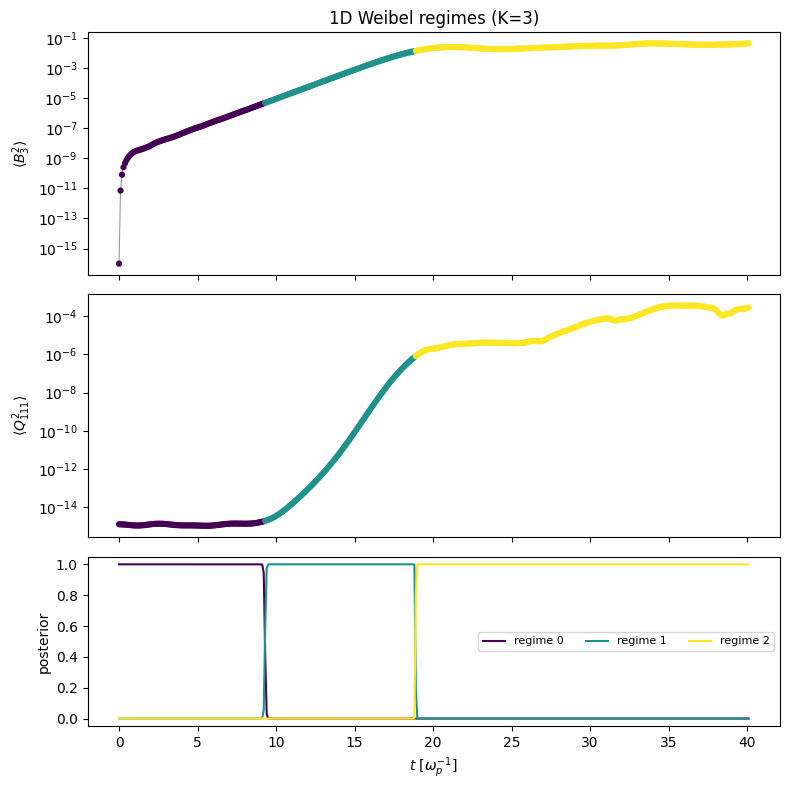

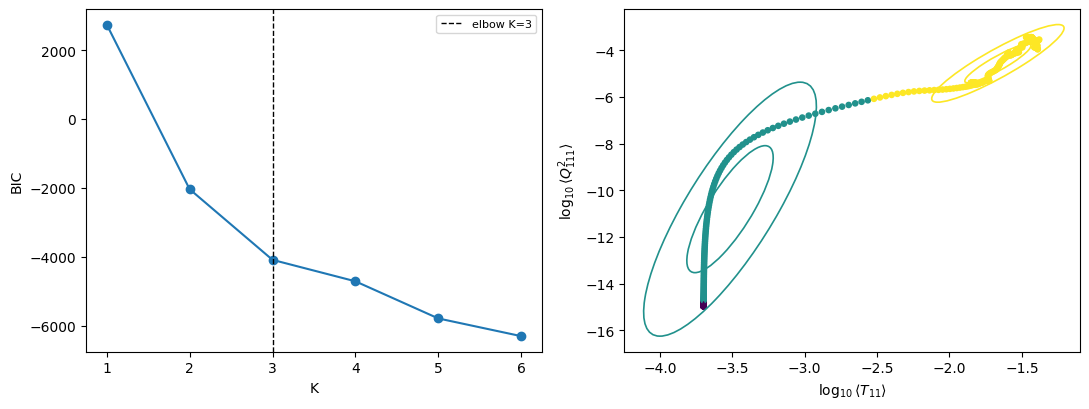

K=1: BIC=2579.2
K=2: BIC=-2143.0
K=3: BIC=-4003.9
K=4: BIC=-4566.8
K=5: BIC=-5455.8
K=6: BIC=-5860.1


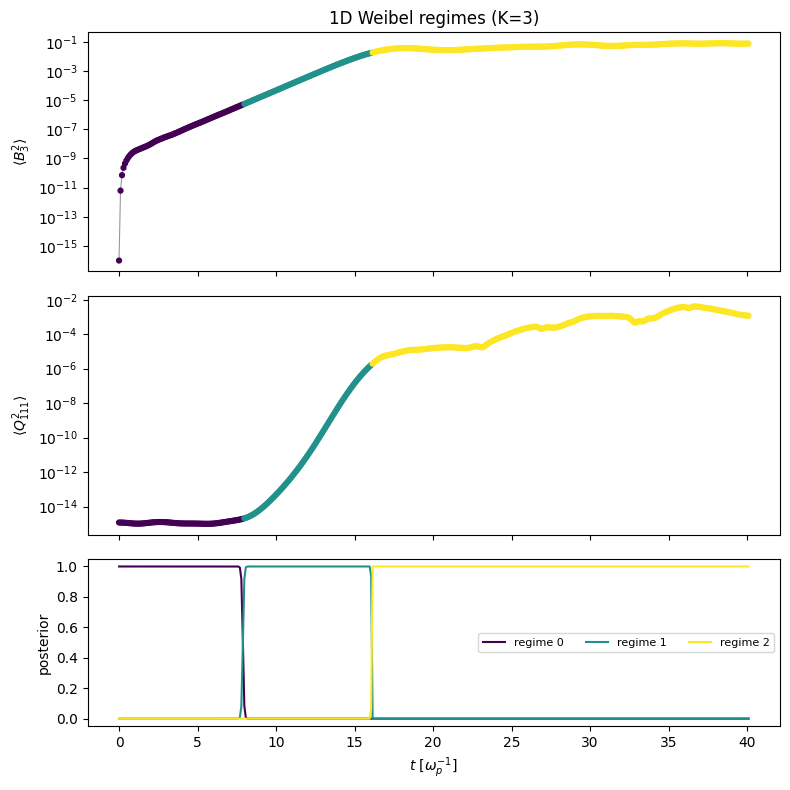

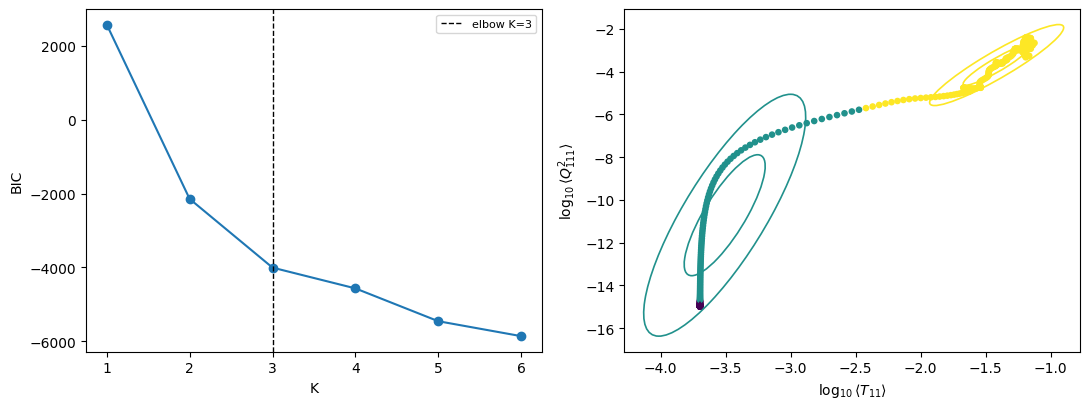

K=1: BIC=2499.9
K=2: BIC=-2106.7
K=3: BIC=-3890.6
K=4: BIC=-4338.1
K=5: BIC=-5025.9
K=6: BIC=-5406.7


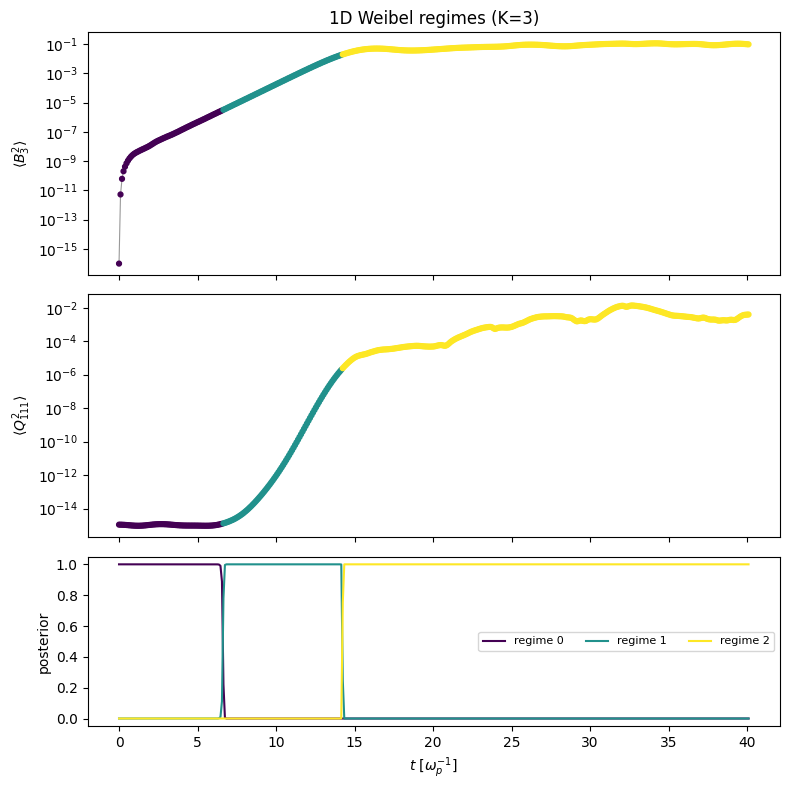

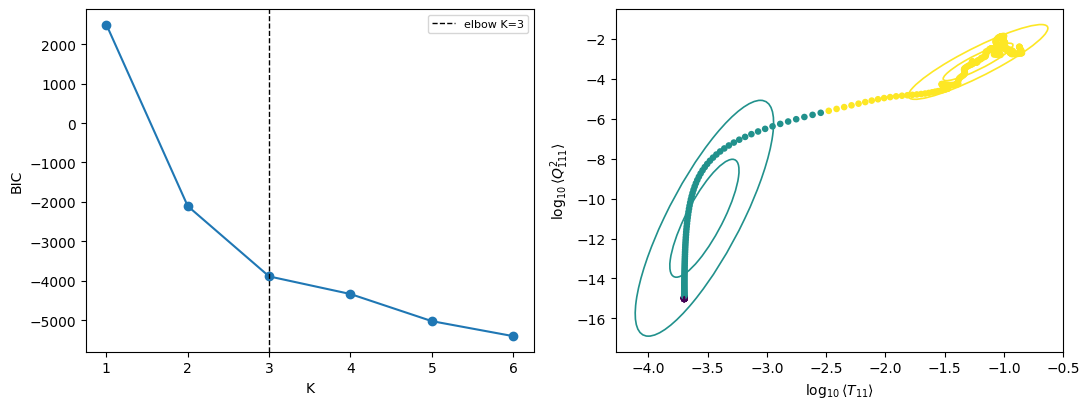

In [11]:
K_FIXED = 3

saturation_interval = {}

for data_set in datasets:
    F = snapshot_features(data_set)
    scaler = StandardScaler().fit(F)
    Xs = scaler.transform(F)

    # Fit Gaussian Mixture Models for different values of K and compute the BIC for each model.
    # Select the best K using the elbow method based on the BIC values.
    bics, models = [], {}
    for k in KS:
        gm = GaussianMixture(n_components=k, covariance_type="full", n_init=20, random_state=SEED).fit(Xs)

        bics.append(gm.bic(Xs))
        models[k] = gm
        print(f"K={k}: BIC={bics[-1]:.1f}")

    k_best = K_FIXED

    gm = models[k_best]
    lab = gm.predict(Xs)
    order = np.argsort([time_array[lab == j].mean() if np.any(lab == j) else np.inf for j in range(k_best)])
    relabel = np.empty(k_best, int)
    relabel[order] = np.arange(k_best)
    labels = relabel[lab]

    reg_q = np.array([F[labels == j, 3].mean() if np.any(labels == j) else -np.inf for j in range(k_best)])
    active = np.where(reg_q >= reg_q.max() - 2.0)[0]

    closure_t_min = float(time_array[np.isin(labels, active)].min())
    closure_iter_min = int(np.where(np.isin(labels, active))[0].min())
    closure_t_max = float(time_array[np.isin(labels, active)].max())
    closure_iter_max = int(np.where(np.isin(labels, active))[0].max())

    active_idx = np.flatnonzero(np.isin(labels, active))
    if not np.all(np.diff(active_idx) == 1):
        print(f"  WARNING: active regimes are not contiguous in {data_set}; window spans a gap")

    saturation_interval[data_set] = [(closure_t_min, closure_t_max), (closure_iter_min, closure_iter_max)]

    cmap = plt.get_cmap("viridis", k_best)
    fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True, height_ratios=[2, 2, 1.4])

    b3sq = 10.0 ** F[:, 0]
    ax[0].plot(time_array, b3sq, "-", color="0.6", lw=0.8)
    ax[0].scatter(time_array, b3sq, c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=12, zorder=3)
    ax[0].set_yscale("log")
    ax[0].set_ylabel(r"$\langle B_3^2\rangle$")
    ax[0].set_title(f"1D Weibel regimes (K={k_best})")

    qsq = 10.0 ** F[:, 3]
    ax[1].plot(time_array, qsq, "-", color="0.6", lw=0.8)
    ax[1].scatter(time_array, qsq, c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=12, zorder=3)
    ax[1].set_yscale("log")
    ax[1].set_ylabel(r"$\langle Q_{111}^2\rangle$")

    probs = gm.predict_proba(Xs)[:, order]
    for j in range(k_best):
        ax[2].plot(time_array, probs[:, j], color=cmap(j), label=f"regime {j}")
    ax[2].set_ylabel("posterior")
    ax[2].set_xlabel(r"$t\ [\omega_p^{-1}]$")
    ax[2].legend(fontsize=8, ncol=k_best)
    plt.tight_layout()
    fig.savefig(GMM_DIR / f"gmm_timeline_{data_set}.png", dpi=200)
    plt.show()
    plt.close(fig)

    # BIC + feature projection
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    ax[0].plot(list(KS), bics, "o-")
    ax[0].axvline(k_best, color="k", ls="--", lw=1, label=f"elbow K={k_best}")
    ax[0].set_xlabel("K")
    ax[0].set_ylabel("BIC")
    ax[0].legend(fontsize=8)

    i, j = 2, 3  # log(B3^2) vs log(Q111^2)
    ax[1].scatter(F[:, i], F[:, j], c=labels, cmap=cmap, vmin=-0.5, vmax=k_best - 0.5, s=14)
    for comp in range(k_best):
        src = order[comp]
        mean = scaler.inverse_transform(gm.means_[src : src + 1])[0]
        cov = gm.covariances_[src][np.ix_([i, j], [i, j])] * np.outer(scaler.scale_[[i, j]], scaler.scale_[[i, j]])
        vals, vecs = np.linalg.eigh(cov)
        ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
        for ns in (1, 2):
            ax[1].add_patch(
                Ellipse(mean[[i, j]], 2 * ns * np.sqrt(vals[1]), 2 * ns * np.sqrt(vals[0]), angle=ang, fc="none", ec=cmap(comp), lw=1.2)
            )
    ax[1].set_xlabel(FEATURE_LABELS[i])
    ax[1].set_ylabel(FEATURE_LABELS[j])
    plt.tight_layout()
    fig.savefig(GMM_DIR / f"gmm_features_{data_set}.png", dpi=200)
    plt.show()
    plt.close(fig)


In [12]:
print(saturation_interval)

{'dx0.1_dt0.095_200ppc_0.3vfl': [(20.52, 40.09), (216, 422)], 'dx0.1_dt0.095_200ppc_0.4vfl': [(16.435, 40.09), (173, 422)], 'dx0.1_dt0.095_200ppc_0.5vfl': [(13.965, 40.09), (147, 422)], 'dx0.1_dt0.095_200ppc_0.6vfl': [(12.445, 40.09), (131, 422)], 'dx0.1_dt0.095_600ppc_0.3vfl': [(18.905, 40.09), (199, 422)], 'dx0.1_dt0.095_600ppc_0.4vfl': [(15.39, 40.09), (162, 422)], 'dx0.1_dt0.095_600ppc_0.5vfl': [(13.205, 40.09), (139, 422)], 'dx0.1_dt0.095_600ppc_0.6vfl': [(11.97, 40.09), (126, 422)], 'dx0.1_dt0.095_1000ppc_0.3vfl': [(20.045, 40.09), (211, 422)], 'dx0.1_dt0.095_1000ppc_0.4vfl': [(19.38, 40.09), (204, 422)], 'dx0.1_dt0.095_1000ppc_0.5vfl': [(16.34, 40.09), (172, 422)], 'dx0.1_dt0.095_1000ppc_0.6vfl': [(12.445, 40.09), (131, 422)], 'dx0.1_dt0.095_1400ppc_0.3vfl': [(22.895, 40.09), (241, 422)], 'dx0.1_dt0.095_1400ppc_0.4vfl': [(18.905, 40.09), (199, 422)], 'dx0.1_dt0.095_1400ppc_0.5vfl': [(15.865, 40.09), (167, 422)], 'dx0.1_dt0.095_1400ppc_0.6vfl': [(12.16, 40.09), (128, 422)], 'dx0.

In [13]:
FD_STENCILS: dict[int, dict[int, float]] = {
    1: {2: -1 / 12, 1: 8 / 12, -1: -8 / 12, -2: 1 / 12},  # d/dx1
    2: {2: -1 / 12, 1: 16 / 12, 0: -30 / 12, -1: 16 / 12, -2: -1 / 12},  # d2/dx1^2
    3: {2: 1 / 2, 1: -2 / 2, -1: 2 / 2, -2: -1 / 2},  # d3/dx1^3
    4: {2: 1, 1: -4, 0: 6, -1: -4, -2: 1},  # d4/dx1^4
}


def d_dx(arr: np.ndarray, order: int = 1, dx: float = DX):
    out = sum(c * np.roll(arr, -j, axis=1) for j, c in FD_STENCILS[order].items())
    return out / dx**order


def block_average(arr: np.ndarray, k: int):
    if k == 1:
        return arr
    n_t, n1 = arr.shape
    return arr.reshape(n_t, n1 // k, k).mean(axis=2)


def add_gradients(d: dict[str, np.ndarray], keys: list[str], orders: tuple[int, ...] = (1,)):
    # Derivatives are saved as d{order}_{key}, e.g. d1_n, d2_T11, etc.
    for k in keys:
        for m in orders:
            d[f"d{m}_{k}"] = d_dx(d[k].astype(np.float64), m, DX).astype(np.float32)
    return d


WILDCARDS: dict[str, callable] = {
    "vfl1^3": lambda d: d["vfl1"].astype(np.float64) ** 3,
    "sqrtT11": lambda d: np.sqrt(np.abs(d["T11"].astype(np.float64))),
    "T11_over_n": lambda d: d["T11"].astype(np.float64) / (d["n"] + 1e-12),
}

# 36 features: 8 base + 7*4 derivatives, plus the wildcards
FEATURES = [
    "n",
    "vfl1",
    "vfl2",
    "vfl3",
    "b3",
    "e1",
    "T11",
    "P11",
    # First derivatives
    "d1_n",
    "d1_T11",
    "d1_P11",
    "d1_vfl1",
    "d1_vfl2",
    "d1_b3",
    "d1_e1",
    # Second derivatives
    "d2_n",
    "d2_T11",
    "d2_P11",
    "d2_vfl1",
    "d2_vfl2",
    "d2_b3",
    "d2_e1",
    # Third derivatives
    "d3_n",
    "d3_T11",
    "d3_P11",
    "d3_vfl1",
    "d3_vfl2",
    "d3_b3",
    "d3_e1",
    # Fourth derivatives
    "d4_n",
    "d4_T11",
    "d4_P11",
    "d4_vfl1",
    "d4_vfl2",
    "d4_b3",
    "d4_e1",
] + list(WILDCARDS)
GRADIENT_KEYS = ["n", "T11", "P11", "vfl1", "vfl2", "b3", "e1"]
GRADIENT_ORDERS = (1, 2, 3, 4)


WILDCARDS["q111"] = lambda d: (
    d["Q111"].astype(np.float64)
    - 3.0 * d["vfl1"].astype(np.float64) * d["P11"].astype(np.float64)
    + 2.0 * d["n"].astype(np.float64) * d["vfl1"].astype(np.float64) ** 3
)
assert "q111" not in FEATURES, "q111 must be a target, not a feature"

TARGET = "q111"


def build_design_matrix(
    sim_labels: list[str],
    time_interval: tuple[float, float],
    feature_names: list[str],
    target: str = "Q111",
    block: int = 1,
    n_workers: int = 8,
):
    iter_min, iter_max = int(time_interval[0] / DT_DUMP), int(time_interval[1] / DT_DUMP)
    sl = slice(iter_min, iter_max)

    X_parts, y_parts, t_parts = [], [], []
    for lab in sim_labels:
        d = add_gradients(
            load_all(
                sim_label=lab, species=ELECTRON_SPECIES, n_workers=n_workers, cache_dir=CACHE_DIR, simulations=SIMS, fields=FIELD_KEYS
            ),
            GRADIENT_KEYS,
            GRADIENT_ORDERS,
        )
        for name, fn in WILDCARDS.items():
            d[name] = np.asarray(fn(d), dtype=np.float64)  # wildcards see base fields + gradients
        feats = [block_average(d[f][sl].astype(np.float64), block) for f in feature_names]

        y = block_average(d[target][sl].astype(np.float64), block)
        n_t, n1 = y.shape

        X_parts.append(np.stack([f.ravel() for f in feats], axis=1))
        y_parts.append(y.ravel())
        t_parts.append(np.repeat(np.arange(iter_min, iter_min + n_t, dtype=np.float32) * DT_DUMP, n1))

    return (
        np.concatenate(X_parts).astype(np.float32),
        np.concatenate(y_parts).astype(np.float32),
        np.concatenate(t_parts).astype(np.float32),
    )


In [14]:
def suffle_divide_labels(sim_labels: list[str], train_frac: float = 0.8, seed: int = 42):
    rng = np.random.default_rng(seed)
    shuffled_labels = rng.permutation(sim_labels)
    n_train = int(len(shuffled_labels) * train_frac)
    train_labels = shuffled_labels[:n_train].tolist()
    test_labels = shuffled_labels[n_train:].tolist()
    return train_labels, test_labels


train_labels, test_labels = suffle_divide_labels(sim_labels, train_frac=0.7, seed=SEED)


def scan_params(label: str) -> tuple[int, float]:
    """'dx0.1_dt0.095_1800ppc_0.6vfl' -> (1800, 0.6)"""
    parts = label.split("_")
    return int(parts[2][:-3]), float(parts[3][:-3])


def stack_runs(labels, target=None, feats=None, block=1, verbose=False):
    target = TARGET if target is None else target
    feats = FEATURES if feats is None else feats
    Xs, ys, ts, gs = [], [], [], []
    for i, lab in enumerate(labels):
        if verbose:
            print(lab)
        X, y, t = build_design_matrix([lab], saturation_interval[lab][0], feats, target=target, block=block)
        Xs.append(X)
        ys.append(y)
        ts.append(t)
        gs.append(np.full(y.size, i, dtype=int))
    return (np.concatenate(Xs), np.concatenate(ys), np.concatenate(ts), np.concatenate(gs))


X_train, y_train, t_train, groups_train = stack_runs(train_labels, verbose=True)
X_test, y_test, t_test, groups_test = stack_runs(test_labels, verbose=True)


dx0.1_dt0.095_600ppc_0.3vfl
dx0.1_dt0.095_1800ppc_0.6vfl
dx0.1_dt0.095_600ppc_0.5vfl
dx0.1_dt0.095_200ppc_0.5vfl
dx0.1_dt0.095_1400ppc_0.4vfl
dx0.1_dt0.095_1800ppc_0.3vfl
dx0.1_dt0.095_200ppc_0.6vfl
dx0.1_dt0.095_1000ppc_0.6vfl
dx0.1_dt0.095_1000ppc_0.5vfl
dx0.1_dt0.095_1000ppc_0.3vfl
dx0.1_dt0.095_200ppc_0.3vfl
dx0.1_dt0.095_1400ppc_0.3vfl
dx0.1_dt0.095_600ppc_0.6vfl
dx0.1_dt0.095_600ppc_0.4vfl
dx0.1_dt0.095_1800ppc_0.5vfl
dx0.1_dt0.095_1800ppc_0.4vfl
dx0.1_dt0.095_1400ppc_0.5vfl
dx0.1_dt0.095_1000ppc_0.4vfl
dx0.1_dt0.095_200ppc_0.4vfl
dx0.1_dt0.095_1400ppc_0.6vfl


In [15]:
def drop_collinear_columns(X, names, tol=1e-8, n_probe=20_000, seed=0):
    rng = np.random.default_rng(seed)
    rows = rng.choice(X.shape[0], n_probe, replace=False) if X.shape[0] > n_probe else slice(None)
    A = np.asarray(X[rows], dtype=np.float64)
    A -= A.mean(0)
    A /= np.linalg.norm(A, axis=0) + 1e-30
    C = np.abs(A.T @ A)  # |correlation| between every pair of columns

    keep = []
    for j in range(X.shape[1]):
        if not any(C[j, k] > 1.0 - tol for k in keep):
            keep.append(j)
    keep = np.array(keep)

    dropped = sorted(set(range(X.shape[1])) - set(keep.tolist()))
    print(f"dedup: {X.shape[1]} -> {keep.size} columns; dropped {[names[j] for j in dropped]}")
    return keep


poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

KEEP = drop_collinear_columns(X_train, poly.get_feature_names_out(FEATURES))
POLY_NAMES = poly.get_feature_names_out(FEATURES)[KEEP]
X_train = X_train[:, KEEP]
X_test = X_test[:, KEEP]


assert list(POLY_NAMES[: len(FEATURES)]) == list(FEATURES)
X_train_raw = X_train[:, : len(FEATURES)]
X_test_raw = X_test[:, : len(FEATURES)]

I_N, I_V1, I_P11 = (FEATURES.index(k) for k in ("n", "vfl1", "P11"))


def raw_Q111(X_raw, y_q111):

    V1, P11, n = (X_raw[:, i].astype(np.float64) for i in (I_V1, I_P11, I_N))
    return y_q111.astype(np.float64) + 3.0 * V1 * P11 - 2.0 * n * V1**3


# Normalization
x_scaler = StandardScaler().fit(X_train)
X_train_scaled = x_scaler.transform(X_train)
X_test_scaled = x_scaler.transform(X_test)


dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']


In [16]:
cv_splits = list(GroupKFold(n_splits=5).split(X_train_scaled, y_train, groups=groups_train))


def fit_lasso_on(X_raw_tr, y_tr, groups_tr, n_splits=5, alpha=None, feats=None):

    feats = FEATURES if feats is None else feats
    pf = PolynomialFeatures(degree=2, include_bias=False)
    Xtr = pf.fit_transform(X_raw_tr)
    pf.keep_ = drop_collinear_columns(Xtr, pf.get_feature_names_out(feats))
    Xtr = Xtr[:, pf.keep_]
    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr).astype(np.float64)
    ytr = y_tr.astype(np.float64)
    if alpha is None:
        splits = list(GroupKFold(n_splits=n_splits).split(Xtr, ytr, groups=groups_tr))
        return LassoCV(cv=splits, random_state=42, n_jobs=-1, max_iter=10000).fit(Xtr, ytr), pf, sc
    return Lasso(alpha=alpha, max_iter=10000).fit(Xtr, ytr), pf, sc


def score_model(model, pf, sc, X_raw, y):
    return r2_score(y, model.predict(sc.transform(pf.transform(X_raw)[:, pf.keep_])))


TARGETS = {
    "Q111": raw_Q111(X_train_raw, y_train),
    "q111": y_train,
}
TARGETS_TEST = {
    "Q111": raw_Q111(X_test_raw, y_test),
    "q111": y_test,
}

RESULTS = {}
for _name in TARGETS:
    _m = LassoCV(cv=cv_splits, random_state=42, n_jobs=-1, max_iter=10000)
    _m.fit(X_train_scaled.astype(np.float64), TARGETS[_name].astype(np.float64))
    _pred = _m.predict(X_test_scaled)
    RESULTS[_name] = {
        "model": _m,
        "y_train": TARGETS[_name],
        "y_test": TARGETS_TEST[_name],
        "y_pred": _pred,
        "alpha": _m.alpha_,
        "n_terms": int(np.count_nonzero(_m.coef_)),
        "r2": r2_score(TARGETS_TEST[_name], _pred),
    }
    print(f"LassoCV [{_name}]: alpha = {_m.alpha_:.3e}, {RESULTS[_name]['n_terms']} nonzero terms, test R^2 = {RESULTS[_name]['r2']:.4f}")

lasso = RESULTS[TARGET]["model"]
y_train = RESULTS[TARGET]["y_train"]
y_test = RESULTS[TARGET]["y_test"]
y_test_pred = RESULTS[TARGET]["y_pred"]
r2_test = RESULTS[TARGET]["r2"]


LassoCV [Q111]: alpha = 3.014e-05, 261 nonzero terms, test R^2 = 0.9195
LassoCV [q111]: alpha = 3.304e-05, 243 nonzero terms, test R^2 = 0.3991


In [17]:
r2_const = r2_score(y_test, np.full_like(y_test, y_train.mean()))

I_dT, I_sqrtT = FEATURES.index("d1_T11"), FEATURES.index("sqrtT11")
GRADIENT_BASELINES = {
    "-k n dT/dx": lambda X: X[:, I_N] * X[:, I_dT],
    "-k n sqrt(T) dT/dx": lambda X: X[:, I_N] * X[:, I_sqrtT] * X[:, I_dT],
}

r2_grad = {}
for _name, _term in GRADIENT_BASELINES.items():
    _lr = LinearRegression().fit(_term(X_train_raw).reshape(-1, 1), y_train)
    r2_grad[_name] = r2_score(y_test, _lr.predict(_term(X_test_raw).reshape(-1, 1)))
    print(f"{_name:22s}  kappa = {-_lr.coef_[0]:+.4e}")

LOCAL_FEATURES = ["n", "vfl1", "vfl2", "vfl3", "b3", "e1", "T11", "P11"]
idx_local = [FEATURES.index(f) for f in LOCAL_FEATURES]
m_loc, pf_loc, sc_loc = fit_lasso_on(X_train_raw[:, idx_local], y_train, groups_train, feats=LOCAL_FEATURES)
r2_local = score_model(m_loc, pf_loc, sc_loc, X_test_raw[:, idx_local], y_test)

baselines = pd.DataFrame([
    {"model": "constant (train mean)", "terms": 0, "R2": r2_const},
    *[{"model": k, "terms": 1, "R2": v} for k, v in r2_grad.items()],
    {"model": "LASSO, local features only", "terms": int(np.count_nonzero(m_loc.coef_)), "R2": r2_local},
    {"model": "LASSO, full library", "terms": RESULTS[TARGET]["n_terms"], "R2": r2_test},
])
print(f"\nBaselines for target {TARGET}:")
print(baselines.to_string(index=False))
print(baselines.to_latex(index=False, float_format="%.4f"))  # paste into the results section


-k n dT/dx              kappa = +8.0426e-03
-k n sqrt(T) dT/dx      kappa = +2.4898e-02
dedup: 44 -> 44 columns; dropped []

Baselines for target q111:
                     model  terms        R2
     constant (train mean)      0 -0.000326
                -k n dT/dx      1  0.033334
        -k n sqrt(T) dT/dx      1  0.045401
LASSO, local features only     10  0.204313
       LASSO, full library    243  0.399138
\begin{tabular}{lrr}
\toprule
model & terms & R2 \\
\midrule
constant (train mean) & 0 & -0.0003 \\
-k n dT/dx & 1 & 0.0333 \\
-k n sqrt(T) dT/dx & 1 & 0.0454 \\
LASSO, local features only & 10 & 0.2043 \\
LASSO, full library & 243 & 0.3991 \\
\bottomrule
\end{tabular}



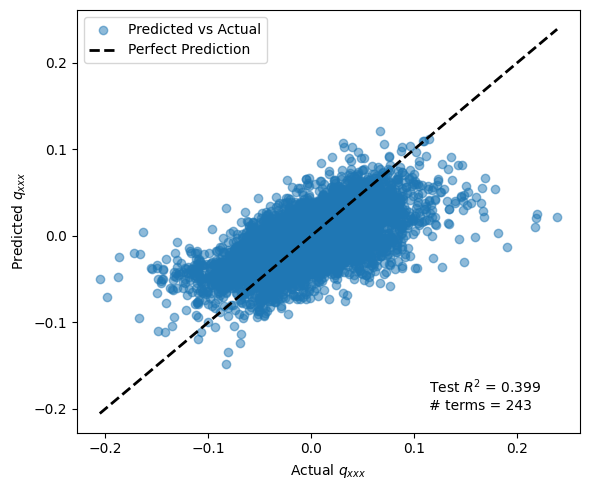

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharex=True, sharey=True)
ax.scatter(y_test, y_test_pred, alpha=0.5, label="Predicted vs Actual")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, label="Perfect Prediction")
ax.set_xlabel(r"Actual $q_{xxx}$")
# ax.set_title(f"{name} Regression ($R^2$ = {r2:.3f})")
ax.legend()
ax.set_ylabel(r"Predicted $q_{xxx}$")
ax.text(
    0.7,
    0.13,
    f"Test $R^2$ = {r2_test:.3f}\n# terms = {RESULTS[TARGET]['n_terms']}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "lasso_true_vs_predicted_test.png", dpi=200)
plt.show()


In [19]:
def plot_closure_map(model=lasso, poly=poly, scaler=x_scaler, sim="test-weibel", feats=FEATURES, block=1):
    """(t, x1) maps of true vs LASSO-predicted TARGET for one sim/species."""
    t0, t1 = saturation_interval[sim][0]
    X, y, t = build_design_matrix([sim], (t0, t1), feats, target=TARGET, block=block)
    n_t = len(np.unique(t))  # rows are raveled (n_t, n1) row-major
    true_map = y.reshape(n_t, -1)

    X_scaled = scaler.transform(poly.transform(X)[:, KEEP])  # same poly + dedup + scaler as X_train/X_test
    pred_map = model.predict(X_scaled).reshape(true_map.shape)

    ext = [0, true_map.shape[1] * block * DX, float(t[0]), float(t[-1])]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    vmax = np.percentile(np.abs(true_map), 99)
    print(f"vmax = {vmax:.3e}")
    for a, arr, title in (
        (ax[0], true_map, "PIC (true)"),
        (ax[1], pred_map, "LASSO closure"),
    ):
        im = a.imshow(arr, origin="lower", aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax, extent=ext)
        a.set_xlabel(r"$x_1\ [c/\omega_p]$")
        a.set_title(rf"${TARGET}$: {title}")
        plt.colorbar(im, ax=a, fraction=0.046, pad=0.04, label=r"$q_{xxx}$ $[m_e c^3]$")
    im2 = ax[2].imshow(np.abs(true_map - pred_map), origin="lower", aspect="auto", cmap="Reds", extent=ext)
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04, label=r"$|q_{xxx}^{\text{true}} - q_{xxx}^{\text{pred}}|$ $[m_e c^3]$")
    ax[2].set_xlabel(r"$x_1\ [c/\omega_p]$")
    ax[2].set_title(rf"${TARGET}$: Absolute Error")
    ax[0].set_ylabel(r"$t\ [\omega_p^{-1}]$")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"lasso_map_{sim}.png", dpi=200)
    return fig


vmax = 3.778e-02


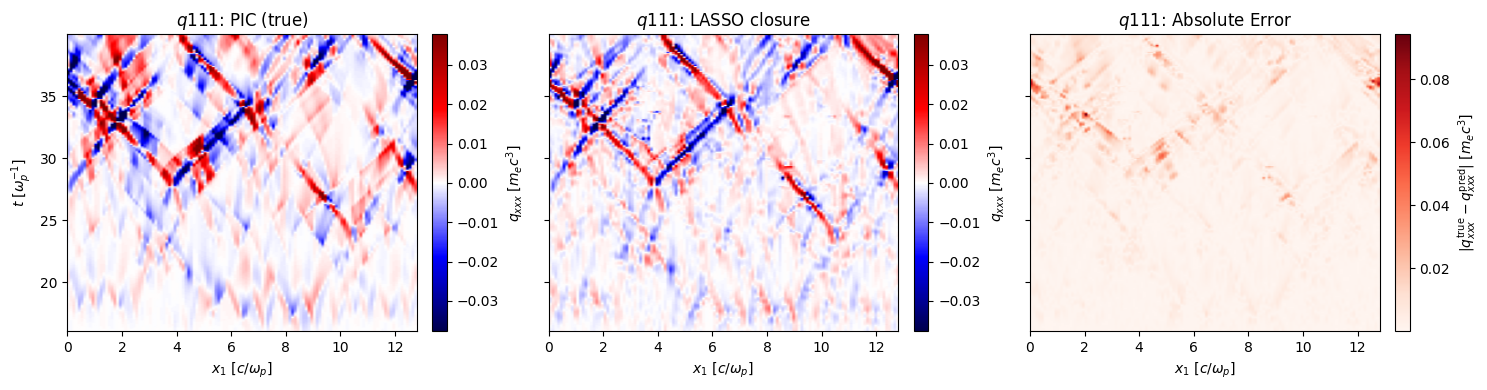

In [20]:
fig = plot_closure_map(sim=test_labels[0])

In [21]:
def lasso_terms(model=lasso, poly=poly, scaler=x_scaler, feats=FEATURES):
    """Nonzero LASSO terms, ordered by importance (|scaled coef|)."""
    df = pd.DataFrame({
        "Term": POLY_NAMES,
        "Coef (scaled)": model.coef_,
        "Coef (physical)": model.coef_ / scaler.scale_,  # undo StandardScaler
    })
    df = df[df["Coef (scaled)"] != 0]
    return df.sort_values(by="Coef (scaled)", key=np.abs, ascending=False)


terms_df = lasso_terms(model=lasso, poly=poly, scaler=x_scaler, feats=FEATURES)
print(terms_df)


               Term  Coef (scaled)  Coef (physical)
301     P11 d2_vfl1   7.080614e-03     7.111391e-03
83         vfl1 P11  -6.754016e-03    -3.804537e-01
75         n vfl1^3   3.357819e-03     3.698143e-01
57        n d2_vfl1   3.305070e-03     3.847833e-04
384  d1_P11 d1_vfl1   2.948792e-03     8.307080e-03
..              ...            ...              ...
676    d3_n d4_vfl2  -1.521682e-06    -8.072857e-13
116       vfl2 vfl3  -1.107274e-06    -2.028150e-02
28            d3_e1  -9.940907e-07    -4.021208e-07
724  d3_vfl1 vfl1^3  -9.619914e-07    -1.638821e-06
212        b3 d3_e1   6.512476e-07     1.144079e-06

[243 rows x 3 columns]


In [22]:
def reconstruct_target(n_terms, model=lasso, poly=poly, scaler=x_scaler, sim=test_labels[0], feats=FEATURES, block=1):
    t0, t1 = saturation_interval[sim][0]
    X, y, t = build_design_matrix([sim], (t0, t1), feats, target=TARGET, block=block)
    X_scaled = scaler.transform(poly.transform(X)[:, KEEP])

    nz = np.flatnonzero(model.coef_)
    order = nz[np.argsort(np.abs(model.coef_[nz]))[::-1]]  # nonzero terms, most important first
    keep = order[:n_terms]

    y_rec = X_scaled[:, keep] @ model.coef_[keep] + model.intercept_

    kept_names = list(POLY_NAMES[keep])
    shown = ", ".join(kept_names[:5]) + (", ..." if len(kept_names) > 5 else "")
    print(f"{sim}: {len(keep)}/{len(nz)} terms -> R^2 = {r2_score(y, y_rec):.5f}  [{shown}]")
    return y, y_rec, t, kept_names


# How fast does the reconstruction converge to the full model as terms are added?
for n in (1, 2, 3, 5, 10, 25, np.count_nonzero(lasso.coef_)):  # last entry = full LASSO support
    y_true, y_rec, t_rec, kept = reconstruct_target(model=lasso, n_terms=n)


dx0.1_dt0.095_1800ppc_0.5vfl: 1/243 terms -> R^2 = 0.39343  [P11 d2_vfl1]
dx0.1_dt0.095_1800ppc_0.5vfl: 2/243 terms -> R^2 = 0.04663  [P11 d2_vfl1, vfl1 P11]
dx0.1_dt0.095_1800ppc_0.5vfl: 3/243 terms -> R^2 = 0.35171  [P11 d2_vfl1, vfl1 P11, n vfl1^3]
dx0.1_dt0.095_1800ppc_0.5vfl: 5/243 terms -> R^2 = 0.15143  [P11 d2_vfl1, vfl1 P11, n vfl1^3, n d2_vfl1, d1_P11 d1_vfl1]
dx0.1_dt0.095_1800ppc_0.5vfl: 10/243 terms -> R^2 = 0.40689  [P11 d2_vfl1, vfl1 P11, n vfl1^3, n d2_vfl1, d1_P11 d1_vfl1, ...]
dx0.1_dt0.095_1800ppc_0.5vfl: 25/243 terms -> R^2 = 0.54354  [P11 d2_vfl1, vfl1 P11, n vfl1^3, n d2_vfl1, d1_P11 d1_vfl1, ...]
dx0.1_dt0.095_1800ppc_0.5vfl: 243/243 terms -> R^2 = 0.57476  [P11 d2_vfl1, vfl1 P11, n vfl1^3, n d2_vfl1, d1_P11 d1_vfl1, ...]


In [23]:
def reconstruct_target_physical(n_terms, model=lasso, poly=poly, scaler=x_scaler, sim=test_labels[0], feats=FEATURES):

    d = add_gradients(
        load_all(sim, ELECTRON_SPECIES, cache_dir=CACHE_DIR, simulations=SIMS, fields=FIELD_KEYS), GRADIENT_KEYS, GRADIENT_ORDERS
    )
    for name, fn in WILDCARDS.items():
        d[name] = np.asarray(fn(d), dtype=np.float64)

    def eval_factor(factor):
        """One factor of a PolynomialFeatures name -> (n_t, nx) array."""
        if factor in d:  # plain feature or wildcard (wildcard names may themselves contain "^")
            return d[factor].astype(np.float64)
        base, _, power = factor.rpartition("^")  # power suffix added by poly, e.g. "P11^2" or "vfl1^3^2"
        return d[base].astype(np.float64) ** int(power)

    names = POLY_NAMES
    nz = np.flatnonzero(model.coef_)
    keep = nz[np.argsort(np.abs(model.coef_[nz]))[::-1]][:n_terms]  # most important first

    coef_phys = model.coef_ / scaler.scale_
    b_eff = model.intercept_ - np.sum(model.coef_[keep] * scaler.mean_[keep] / scaler.scale_[keep])

    recon = np.full(d["n"].shape, b_eff, dtype=np.float64)
    for j in keep:
        term_value = np.ones_like(recon)
        for factor in names[j].split(" "):
            term_value *= eval_factor(factor)
        recon += coef_phys[j] * term_value

    eq = " + ".join(f"({coef_phys[j]:+.3e})*{names[j]}" for j in keep)
    print(f"{TARGET} ~ {eq} + ({b_eff:+.3e})")
    return recon


new_diagnostics = reconstruct_target_physical(model=lasso, n_terms=2)


q111 ~ (+7.111e-03)*P11 d2_vfl1 + (-3.805e-01)*vfl1 P11 + (-1.890e-04)


In [24]:
sim_fvu = test_labels[0]
data = load_all(sim_fvu, ELECTRON_SPECIES, simulations=SIMS, cache_dir=CACHE_DIR, fields=FIELD_KEYS)

y_true_full = np.asarray(WILDCARDS[TARGET](data) if TARGET in WILDCARDS else data[TARGET], dtype=np.float64)


In [25]:
it0, it1 = (int(t / DT_DUMP) for t in saturation_interval[sim_fvu][0])
sl_fvu = slice(it0, it1)

FVU = np.mean((new_diagnostics[sl_fvu] - y_true_full[sl_fvu]) ** 2) / np.var(y_true_full[sl_fvu])
FVU_all = np.mean((new_diagnostics - y_true_full) ** 2) / np.var(y_true_full)
print(f"{TARGET} on {sim_fvu}: variance unexplained = {100 * FVU:.2f}% in the saturation window, {100 * FVU_all:.2f}% over the full run")


q111 on dx0.1_dt0.095_1800ppc_0.5vfl: variance unexplained = 95.34% in the saturation window, 95.39% over the full run


In [26]:
per_run = pd.DataFrame([
    {
        "ppc": scan_params(lab)[0],
        "vfl": scan_params(lab)[1],
        "n_samples": int(np.sum(groups_test == i)),
        "R2": r2_score(y_test[groups_test == i], y_test_pred[groups_test == i]),
    }
    for i, lab in enumerate(test_labels)
]).sort_values(["vfl", "ppc"])
print(per_run.to_string(index=False))


 ppc  vfl  n_samples       R2
 200  0.4      32000 0.611514
1000  0.4      27904 0.576187
1800  0.4      28544 0.533980
1400  0.5      32640 0.401076
1800  0.5      32384 0.574760
1400  0.6      37632 0.346979


dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_200ppc_0.3vfl: R^2 = -0.1760
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_200ppc_0.4vfl: R^2 = 0.5928
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_200ppc_0.5vfl: R^2 = 0.5205
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_200ppc_0.6vfl: R^2 = 0.4172
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_600ppc_0.3vfl: R^2 = 0.1573
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_600ppc_0.4vfl: R^2 = 0.4832
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_600ppc_0.5vfl: R^2 = 0.4937
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
  held out dx0.1_dt0.095_600ppc_0.6vfl: R^2 = 0.4464
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sq

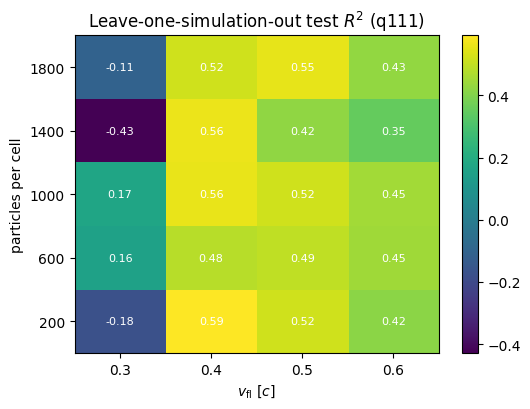

In [27]:
RUN_LOSO = True  # ~20 fits, set False to skip

if RUN_LOSO:
    rng_loso = np.random.default_rng(0)
    N_LOSO_FIT = 120_000

    loso = []
    for held in sim_labels:
        Xtr, ytr, _, gtr = stack_runs([s for s in sim_labels if s != held])
        if Xtr.shape[0] > N_LOSO_FIT:
            keep = rng_loso.choice(Xtr.shape[0], N_LOSO_FIT, replace=False)
            Xtr, ytr, gtr = Xtr[keep], ytr[keep], gtr[keep]

        m_loso, pf_loso, sc_loso = fit_lasso_on(Xtr, ytr, gtr, alpha=lasso.alpha_)
        Xte, yte, _, _ = stack_runs([held])

        p, v = scan_params(held)
        loso.append({"ppc": p, "vfl": v, "R2": score_model(m_loso, pf_loso, sc_loso, Xte, yte)})
        print(f"  held out {held}: R^2 = {loso[-1]['R2']:.4f}")
        del Xtr, ytr, Xte, yte

    grid = pd.DataFrame(loso).pivot_table(index="ppc", columns="vfl", values="R2")
    print(grid.to_string())

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    im = ax.imshow(grid.values, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns)), [str(c) for c in grid.columns])
    ax.set_yticks(range(len(grid.index)), [str(i) for i in grid.index])
    ax.set_xlabel(r"$v_{\rm fl}\ [c]$")
    ax.set_ylabel("particles per cell")
    ax.set_title(rf"Leave-one-simulation-out test $R^2$ ({TARGET})")
    for (a_, b_), val in np.ndenumerate(grid.values):
        ax.text(b_, a_, f"{val:.2f}", ha="center", va="center", color="w", fontsize=8)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f"r2_scan_grid_{TARGET}.png", dpi=200)
    plt.show()


In [28]:
EXTRAP = {
    "hold out v_fl = 0.6 (strongest anisotropy)": lambda lab: scan_params(lab)[1] == 0.6,
    "hold out v_fl = 0.3 (weakest anisotropy)": lambda lab: scan_params(lab)[1] == 0.3,
    "hold out ppc = 200 (noisiest)": lambda lab: scan_params(lab)[0] == 200,
}

extrap_rows = []
for _name, _is_test in EXTRAP.items():
    tr_labs = [s for s in sim_labels if not _is_test(s)]
    te_labs = [s for s in sim_labels if _is_test(s)]

    Xtr, ytr, _, gtr = stack_runs(tr_labs)
    Xte, yte, _, _ = stack_runs(te_labs)

    m_ex, pf_ex, sc_ex = fit_lasso_on(Xtr, ytr, gtr, alpha=None)
    r2_ex = score_model(m_ex, pf_ex, sc_ex, Xte, yte)

    overlap = len(set(np.flatnonzero(m_ex.coef_)) & set(np.flatnonzero(lasso.coef_)))
    extrap_rows.append({
        "split": _name,
        "train_runs": len(tr_labs),
        "test_runs": len(te_labs),
        "alpha": m_ex.alpha_,
        "terms": int(np.count_nonzero(m_ex.coef_)),
        "support_overlap": f"{overlap}/{np.count_nonzero(lasso.coef_)}",
        "R2": r2_ex,
    })
    print(
        f"{_name}: R^2 = {r2_ex:.4f}  (alpha={m_ex.alpha_:.3e}, {extrap_rows[-1]['terms']} terms, overlap {extrap_rows[-1]['support_overlap']})"
    )
    del Xtr, ytr, Xte, yte

extrapolation = pd.DataFrame(extrap_rows)
print(extrapolation.to_latex(index=False, float_format="%.4f"))


dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
hold out v_fl = 0.6 (strongest anisotropy): R^2 = 0.4332  (alpha=5.437e-06, 443 terms, overlap 168/243)
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
hold out v_fl = 0.3 (weakest anisotropy): R^2 = -0.2050  (alpha=8.887e-06, 466 terms, overlap 191/243)
dedup: 819 -> 817 columns; dropped ['n T11_over_n', 'sqrtT11^2']
hold out ppc = 200 (noisiest): R^2 = 0.4430  (alpha=9.689e-06, 438 terms, overlap 184/243)
\begin{tabular}{lrrrrlr}
\toprule
split & train_runs & test_runs & alpha & terms & support_overlap & R2 \\
\midrule
hold out v_fl = 0.6 (strongest anisotropy) & 15 & 5 & 0.0000 & 443 & 168/243 & 0.4332 \\
hold out v_fl = 0.3 (weakest anisotropy) & 15 & 5 & 0.0000 & 466 & 191/243 & -0.2050 \\
hold out ppc = 200 (noisiest) & 16 & 4 & 0.0000 & 438 & 184/243 & 0.4430 \\
\bottomrule
\end{tabular}



Sparse model discovery following [Alves & Fiuza, PRR 4, 033192 (2022)](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.4.033192): a 1-by-1 sequentially-thresholded least-squares (STLSQ) elimination path across K folds gives the best $M$-term model for every $M$, the accuracy-vs-complexity Pareto front, and the stability of the discovered model form.

In [29]:
# This code was adapted from https://github.com/epalves/data-driven-plasma


def plot_pareto_front_analysis(regression_results, pareto_pos=None):
    plt.figure(figsize=(12, 5))
    if pareto_pos is not None:
        plt.axvline(x=pareto_pos, c="k", ls="--", lw=1)
        # plt.axvline(x=2, c = 'k', ls = '--', lw=1)
    plt.scatter(
        regression_results["num_non_zero_terms"],
        regression_results["mse_train"] / regression_results["error_norm"],
        label=r"$E[\epsilon_{train}^2]$",
        facecolors="None",
        edgecolors="C1",
        s=60,
    )

    plt.scatter(
        regression_results["num_non_zero_terms"],
        regression_results["mse_test"] / regression_results["error_norm"],
        label=r"$E[\epsilon_{test}^2]$",
        facecolors="C3",
        s=15,
    )

    plt.xlabel(r"$\#$ nonzero terms")
    plt.ylabel(r"$E[\epsilon^2]$")
    plt.yscale("log")
    #     plt.ylim(5e-2,5)
    plt.xlim(-1, 30.5)
    plt.xticks(range(0, 32, 2))
    plt.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "pareto_front_analysis.png", dpi=200)


def STLS_1by1(X, y, xi=None):
    """Sequentially thresholded least-squares"""
    m, d = X.shape

    if np.all(xi is None):
        xi = np.linalg.lstsq(X, y, rcond=None)[0]

    lam = np.min(np.abs(xi[np.nonzero(xi)]))

    big_coefs = np.abs(xi) > lam
    small_coefs = np.logical_not(big_coefs)
    xi[small_coefs] = 0

    num_relevant = sum(big_coefs)
    if num_relevant == 0:
        return np.zeros(d), lam

    else:
        xi[big_coefs] = np.linalg.lstsq(X[:, big_coefs], y, rcond=None)[0]
        return xi, lam


def Kfold_STLS_regression__1by1(Theta, Y, K_folds=10, normalize_Theta=True, groups=None):
    if normalize_Theta:
        Theta_Norm = np.sqrt(np.var(Theta, axis=0))
        Theta_Norm[0] = 1
    else:
        Theta_Norm = 1

    # error_Norm = np.mean(Y**2) # normalize errors to typical values of Y
    error_Norm = np.var(Y)  # normalize errors to typical values of Y

    # Subsampling rows only partially decorrelates neighbouring cells, so a shuffled
    # KFold still scores a fold against near-duplicates of its own training points.
    # With `groups` (one id per simulation) the Pareto test curve measures the same
    # thing the held-out runs do.
    if groups is None:
        kf = KFold(n_splits=K_folds, random_state=8, shuffle=True)
        split = kf.split(Theta)
    else:
        kf = GroupKFold(n_splits=K_folds)
        split = kf.split(Theta, groups=groups)

    # Range of regularization parameters for STLS regression
    n_terms = Theta.shape[-1]

    n_iters = n_terms
    lamdas = np.zeros(n_terms)
    coefficients_evol = np.zeros((K_folds, n_iters, n_terms))
    mse_train = np.zeros((K_folds, n_iters))
    mse_test = np.zeros((K_folds, n_iters))

    number_non_zero_terms = np.zeros((K_folds, n_iters))

    k = 0
    for train_index, test_index in split:
        print("K-fold #", k)
        Theta_train, Theta_test = Theta[train_index], Theta[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        STLS_coefs = None
        for i in range(n_iters):
            STLS_coefs, lamdas[i] = STLS_1by1(X=Theta_train / Theta_Norm, y=Y_train[:, 0], xi=STLS_coefs)

            coefficients_evol[k, i, :] = STLS_coefs / Theta_Norm

            mse_train[k, i] = np.mean((Y_train[:, 0] - np.dot(Theta_train / Theta_Norm, STLS_coefs)) ** 2)
            mse_test[k, i] = np.mean((Y_test[:, 0] - np.dot(Theta_test / Theta_Norm, STLS_coefs)) ** 2)

        number_non_zero_terms[k, :] = [np.sum(np.abs(coefficients_evol[k, i, :]) > 0) for i in range(n_iters)]

        k += 1

    regression_results = {}
    regression_results["coeff_evol"] = coefficients_evol
    regression_results["num_non_zero_terms"] = number_non_zero_terms
    regression_results["mse_test"] = mse_test
    regression_results["mse_train"] = mse_train
    regression_results["error_norm"] = error_Norm
    regression_results["K"] = K_folds
    regression_results["lamdas"] = lamdas

    return regression_results


def LS_estimation_for_given_sparsity_pattern(Theta, Y, description, sparsity_pattern):
    # Final unbaised regression on full data
    final_Xi = np.dot(np.linalg.pinv(Theta[:, sparsity_pattern]), Y[:, 0])
    print("Nonzero terms:", np.array(description)[sparsity_pattern])
    print("Mean Coefficient values (on full data):", final_Xi)

    return final_Xi


def discovered_Mterm_models(regression_results, description, M=1):
    unique_Mterm_models = np.unique(regression_results["coeff_evol"][(regression_results["num_non_zero_terms"][:, :] == M)], axis=0)
    idx_non_zero_coefs_Mterm_models = np.sum(unique_Mterm_models**2, axis=0) > 0

    plt.figure(figsize=(6, 5))
    max_abs_coef = np.max(np.abs(unique_Mterm_models))
    plt.imshow(
        unique_Mterm_models[:, idx_non_zero_coefs_Mterm_models].T,
        origin="lower",
        cmap="RdBu_r",
        aspect="auto",
        vmin=-1.05 * max_abs_coef,
        vmax=1.05 * max_abs_coef,
    )

    # plt.yticks(range(sum(idx_non_zero_coefs_Mterm_models)), np.array(description)[idx_non_zero_coefs_Mterm_models], rotation='0')
    description_2 = [r"$" + descr + "$" for descr in description]
    plt.yticks(range(sum(idx_non_zero_coefs_Mterm_models)), np.array(description_2)[idx_non_zero_coefs_Mterm_models], rotation=0)
    plt.xlabel(str(M) + " term models")
    plt.ylabel("terms")
    num_unique_models = unique_Mterm_models.shape[0]
    plt.xlim(-0.5, num_unique_models - 0.5)
    plt.xticks(range(num_unique_models), range(1, num_unique_models + 1))
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"discovered_{M}term_models.png", dpi=200)


K-fold # 0
K-fold # 1
K-fold # 2
K-fold # 3
K-fold # 4
K-fold # 5
K-fold # 6
K-fold # 7
K-fold # 8
K-fold # 9


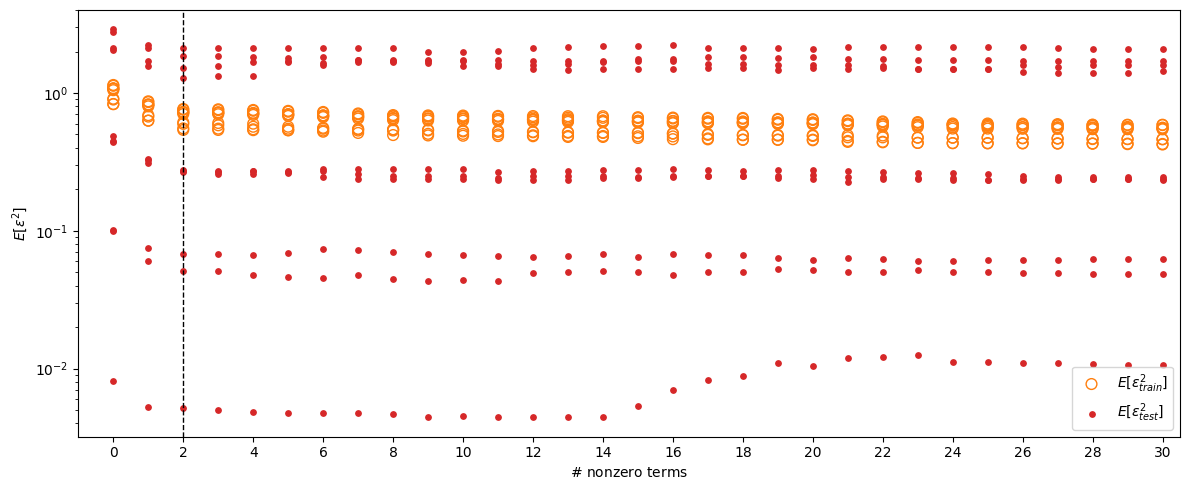

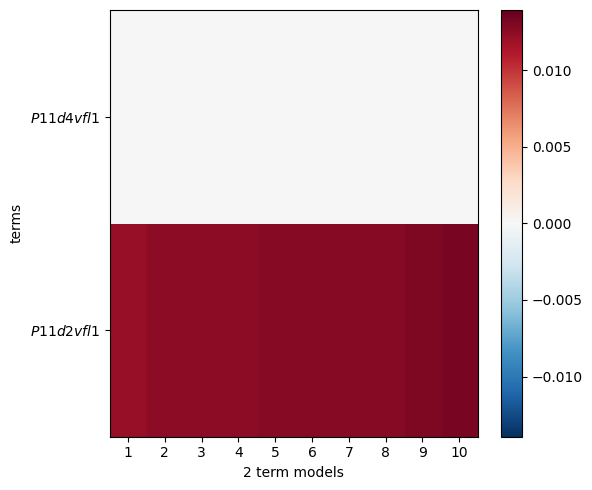

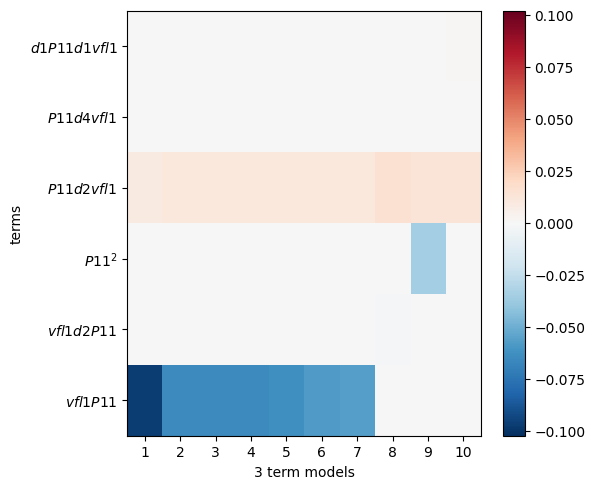

In [30]:
rng_pareto = np.random.default_rng(0)
cols = np.flatnonzero(lasso.coef_)
rows = rng_pareto.choice(X_train.shape[0], size=min(12_000, X_train.shape[0]), replace=False)
poly_names = POLY_NAMES


def tex_name(name):
    """Mathtext-safe label: brace nested powers, e.g. 'vfl1^3^2' -> '{vfl1^3}^2'."""
    parts = []
    for f in name.split(" "):
        if f.count("^") > 1:
            i = f.rindex("^")
            f = "{" + f[:i] + "}" + f[i:]
        parts.append(f)
    # substitue "_" by "\_" for mathtext safety, e.g. "d1_T11" -> "d1\_T11"
    parts = [p.replace("_", r" ") for p in parts]
    return " ".join(parts)


description = ["1"] + [tex_name(poly_names[j]) for j in cols]

if X_train.shape[1] == len(FEATURES):
    X_train = poly.transform(X_train)[:, KEEP]
if X_test.shape[1] == len(FEATURES):
    X_test = poly.transform(X_test)[:, KEEP]

Theta = np.column_stack([np.ones(rows.size), X_train[rows][:, cols]]).astype(np.float64)
Y = y_train[rows].astype(np.float64).reshape(-1, 1)

reg_results = Kfold_STLS_regression__1by1(Theta=Theta, Y=Y, K_folds=10, normalize_Theta=True, groups=groups_train[rows])

plot_pareto_front_analysis(reg_results, pareto_pos=2)
discovered_Mterm_models(reg_results, description, M=2)
discovered_Mterm_models(reg_results, description, M=3)

# Refit each discovered 2-term sparsity pattern on the full training data, score on test
Theta_full = np.column_stack([np.ones(X_train.shape[0]), X_train[:, cols]]).astype(np.float64)
Theta_test = np.column_stack([np.ones(X_test.shape[0]), X_test[:, cols]]).astype(np.float64)


In [31]:
M = 4
patterns = np.unique(np.abs(reg_results["coeff_evol"][reg_results["num_non_zero_terms"] == M]) > 0, axis=0)
for pattern in patterns:
    idx = np.flatnonzero(pattern)
    xi = LS_estimation_for_given_sparsity_pattern(Theta_full, y_train.astype(np.float64).reshape(-1, 1), description, idx)
    terms = [poly_names[cols[j - 1]] if j > 0 else "" for j in idx]  # Theta column 0 is the intercept
    eq = " + ".join(f"({c:+.4e})" + (f"*{t}" if t else "") for c, t in zip(xi, terms, strict=True))
    print(f"  {TARGET} ~ {eq}")
    print(f"  test R^2 = {r2_score(y_test, Theta_test[:, idx] @ xi):.4f}")


Nonzero terms: ['P11 d2 vfl1' 'P11 d4 vfl1' 'd1 P11 d1 vfl1' 'd1 vfl1 d3 P11']
Mean Coefficient values (on full data): [1.30756194e-02 4.20236469e-05 2.97636503e-03 1.55147508e-05]
  q111 ~ (+1.3076e-02)*P11 d2_vfl1 + (+4.2024e-05)*P11 d4_vfl1 + (+2.9764e-03)*d1_P11 d1_vfl1 + (+1.5515e-05)*d1_vfl1 d3_P11
  test R^2 = 0.3258
Nonzero terms: ['P11^2' 'P11 d2 P11' 'P11 d2 vfl1' 'P11 d4 vfl1']
Mean Coefficient values (on full data): [-4.12956817e-02 -2.28466151e-04  1.32756753e-02  4.30167085e-05]
  q111 ~ (-4.1296e-02)*P11^2 + (-2.2847e-04)*P11 d2_P11 + (+1.3276e-02)*P11 d2_vfl1 + (+4.3017e-05)*P11 d4_vfl1
  test R^2 = 0.3236
Nonzero terms: ['vfl1 P11' 'vfl1 d2 P11' 'P11 d2 vfl1' 'P11 d4 vfl1']
Mean Coefficient values (on full data): [-1.10732622e-01 -1.49024368e-03  1.19720650e-02  3.77440319e-05]
  q111 ~ (-1.1073e-01)*vfl1 P11 + (-1.4902e-03)*vfl1 d2_P11 + (+1.1972e-02)*P11 d2_vfl1 + (+3.7744e-05)*P11 d4_vfl1
  test R^2 = 0.3258
Nonzero terms: ['n vfl1^3' 'vfl1 P11' 'P11 d2 vfl1' 'P11 d